In [1]:
#!/usr/bin/env python
# coding: utf-8

# =============================================================================
# 导入库，设置绘图参数，加载数据和模型
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pickle
import json
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

Path('figures/independent_test').mkdir(parents=True, exist_ok=True)

sns.set_context("paper")
sns.set_palette('muted')

ss   = 10
sss  = 8
ssss = 6

matplotlib.rcParams['figure.figsize']   = (3.2, 2.8)
matplotlib.rcParams['figure.dpi']       = 600
matplotlib.rcParams['font.sans-serif']  = ['Arial']
matplotlib.rcParams['font.family']      = 'sans-serif'
matplotlib.rcParams['font.style']       = 'normal'
matplotlib.rcParams['font.weight']      = 'bold'
matplotlib.rcParams['axes.labelweight'] = 'bold'
matplotlib.rcParams['axes.titlesize']   = sss
matplotlib.rcParams['legend.fontsize']  = ss
matplotlib.rcParams['axes.labelsize']   = ss
matplotlib.rcParams['xtick.labelsize']  = ss
matplotlib.rcParams['ytick.labelsize']  = ss
matplotlib.rcParams['axes.linewidth']   = 0.6
matplotlib.rcParams['lines.linewidth']  = 1.0
matplotlib.rcParams['axes.grid']        = False

COLOR_MAP = {
    'edge':        'tab:orange',
    'interior':    'tab:blue',
    'cv':          'steelblue',
    'independent': 'coral'
}

scatter_s     = 20
ref_line_size = 0.8

df_5x6 = pd.read_csv('data/independent_test_set.csv')

with open('models/xgb/xgb_final_model.pkl', 'rb') as f:
    model_package = pickle.load(f)
with open('models/xgb/xgb_results.json', 'r') as f:
    cv_results = json.load(f)

xgb_model        = model_package['model']
scaler           = model_package['scaler']
feature_cols     = model_package['feature_cols']
target_col       = model_package['target_col']
best_params      = model_package['best_params']
EDGE_THRESHOLD   = model_package['edge_threshold']
ATOM_TYPE_LABELS = model_package['atom_type_labels']
ATOM_TYPE_COLS   = ['T_O', 'T_C', 'T_Ti1', 'T_Ti2']

cv_test = cv_results['cv_results']['test']

X_5x6        = df_5x6[feature_cols].values
y_true       = df_5x6[target_col].values
X_5x6_scaled = scaler.transform(X_5x6)

D_E        = df_5x6['D_E'].values
atom_types = df_5x6[ATOM_TYPE_COLS].values

# =============================================================================
# 辅助函数
# =============================================================================

def calculate_metrics(y_true, y_pred):
    return {
        'mae':       float(mean_absolute_error(y_true, y_pred)),
        'rmse':      float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'r2':        float(r2_score(y_true, y_pred)),
        'n_samples': int(len(y_true))
    }

def classify_and_evaluate(y_true, y_pred, D_E, atom_types):
    results = {}
    results['overall'] = calculate_metrics(y_true, y_pred)
    edge_mask     = D_E < EDGE_THRESHOLD
    interior_mask = ~edge_mask
    results['edge']     = calculate_metrics(y_true[edge_mask],     y_pred[edge_mask])     if edge_mask.sum()     > 0 else {'mae': np.nan, 'rmse': np.nan, 'r2': np.nan, 'n_samples': 0}
    results['interior'] = calculate_metrics(y_true[interior_mask], y_pred[interior_mask]) if interior_mask.sum() > 0 else {'mae': np.nan, 'rmse': np.nan, 'r2': np.nan, 'n_samples': 0}
    results['by_atom_type'] = {}
    for idx, label in enumerate(ATOM_TYPE_LABELS):
        mask = atom_types[:, idx] == 1
        results['by_atom_type'][label] = calculate_metrics(y_true[mask], y_pred[mask]) if mask.sum() > 0 \
            else {'mae': np.nan, 'rmse': np.nan, 'r2': np.nan, 'n_samples': 0}
    return results

def apply_charge_neutrality_correction(df_predictions):
    """按电荷绝对值加权，对每个结构应用电中性校正"""
    df_corrected = df_predictions.copy()
    df_corrected['y_pred_corrected']  = 0.0
    df_corrected['correction_amount'] = 0.0
    df_corrected['correction_weight'] = 0.0
    df_corrected['Q_total_before']    = 0.0
    for structure_id in df_corrected['structure_id'].unique():
        mask    = df_corrected['structure_id'] == structure_id
        charges = df_corrected.loc[mask, 'y_pred'].values
        Q_total = charges.sum()
        abs_charges = np.abs(charges)
        s = abs_charges.sum()
        weights = abs_charges / s if s > 1e-10 else np.ones(len(charges)) / len(charges)
        corrections = weights * Q_total
        df_corrected.loc[mask, 'y_pred_corrected']  = charges - corrections
        df_corrected.loc[mask, 'correction_amount'] = corrections
        df_corrected.loc[mask, 'correction_weight'] = weights
        df_corrected.loc[mask, 'Q_total_before']    = Q_total
    df_corrected['error_corrected']     = df_corrected['y_pred_corrected'] - df_corrected['y_true']
    df_corrected['abs_error_corrected'] = df_corrected['error_corrected'].abs()
    return df_corrected

# =============================================================================
# 预测，电中性校正，计算评分
# =============================================================================

y_pred = xgb_model.predict(X_5x6_scaled)

predictions_data = [{'atom_index': i, 'structure_id': df_5x6.iloc[i]['structure_id'],
                     'D_E': float(D_E[i]),
                     'T_O': int(df_5x6.iloc[i]['T_O']), 'T_C': int(df_5x6.iloc[i]['T_C']),
                     'T_Ti1': int(df_5x6.iloc[i]['T_Ti1']), 'T_Ti2': int(df_5x6.iloc[i]['T_Ti2']),
                     'y_true': float(y_true[i]), 'y_pred': float(y_pred[i]),
                     'error': float(y_pred[i]-y_true[i]), 'abs_error': float(abs(y_pred[i]-y_true[i]))}
                    for i in range(len(df_5x6))]
df_predictions = pd.DataFrame(predictions_data)

df_predictions = apply_charge_neutrality_correction(df_predictions)
df_predictions['error_corrected']     = df_predictions['y_pred_corrected'] - df_predictions['y_true']
df_predictions['abs_error_corrected'] = df_predictions['error_corrected'].abs()

Q_total_before = df_predictions.groupby('structure_id')['Q_total_before'].first()
Q_total_after  = df_predictions.groupby('structure_id')['y_pred_corrected'].sum()

print(f"独立测试集: {df_5x6['structure_id'].nunique()} 个结构，{len(df_5x6)} 个原子")
print(f"校正前平均|Q_total|: {np.abs(Q_total_before).mean():.6f} e")
print(f"校正后平均|Q_total|: {np.abs(Q_total_after).mean():.2e} e")

y_pred_before = df_predictions['y_pred'].values
y_pred_after  = df_predictions['y_pred_corrected'].values

ind_results_before = classify_and_evaluate(y_true, y_pred_before, D_E, atom_types)
ind_results_after  = classify_and_evaluate(y_true, y_pred_after,  D_E, atom_types)
ind_results        = ind_results_before

mae_improvement = (ind_results_before['overall']['mae'] - ind_results_after['overall']['mae']) / \
                   ind_results_before['overall']['mae'] * 100
ind_ratio = ind_results['edge']['mae'] / ind_results['interior']['mae']

overall_change  = (ind_results['overall']['mae'] - cv_test['overall']['mae_mean']) / cv_test['overall']['mae_mean'] * 100
edge_change     = (ind_results['edge']['mae']     - cv_test['edge']['mae_mean'])    / cv_test['edge']['mae_mean']    * 100
interior_change = (ind_results['interior']['mae'] - cv_test['interior']['mae_mean'])/ cv_test['interior']['mae_mean']* 100
cv_ratio        = cv_test['edge']['mae_mean'] / cv_test['interior']['mae_mean']
ind_ratio_after = ind_results_after['edge']['mae'] / ind_results_after['interior']['mae']

print(f"\n校正前 MAE: {ind_results_before['overall']['mae']:.5f}  "
      f"RMSE: {ind_results_before['overall']['rmse']:.5f}  R²: {ind_results_before['overall']['r2']:.6f}")
print(f"校正后 MAE: {ind_results_after['overall']['mae']:.5f}  "
      f"RMSE: {ind_results_after['overall']['rmse']:.5f}  R²: {ind_results_after['overall']['r2']:.6f}")
print(f"MAE改善: {mae_improvement:+.2f}%  |  与CV测试集变化: {overall_change:+.2f}%")



独立测试集: 19 个结构，8189 个原子
校正前平均|Q_total|: 0.567587 e
校正后平均|Q_total|: 7.65e-16 e

校正前 MAE: 0.00446  RMSE: 0.01516  R²: 0.999651
校正后 MAE: 0.00474  RMSE: 0.01503  R²: 0.999657
MAE改善: -6.30%  |  与CV测试集变化: -9.56%


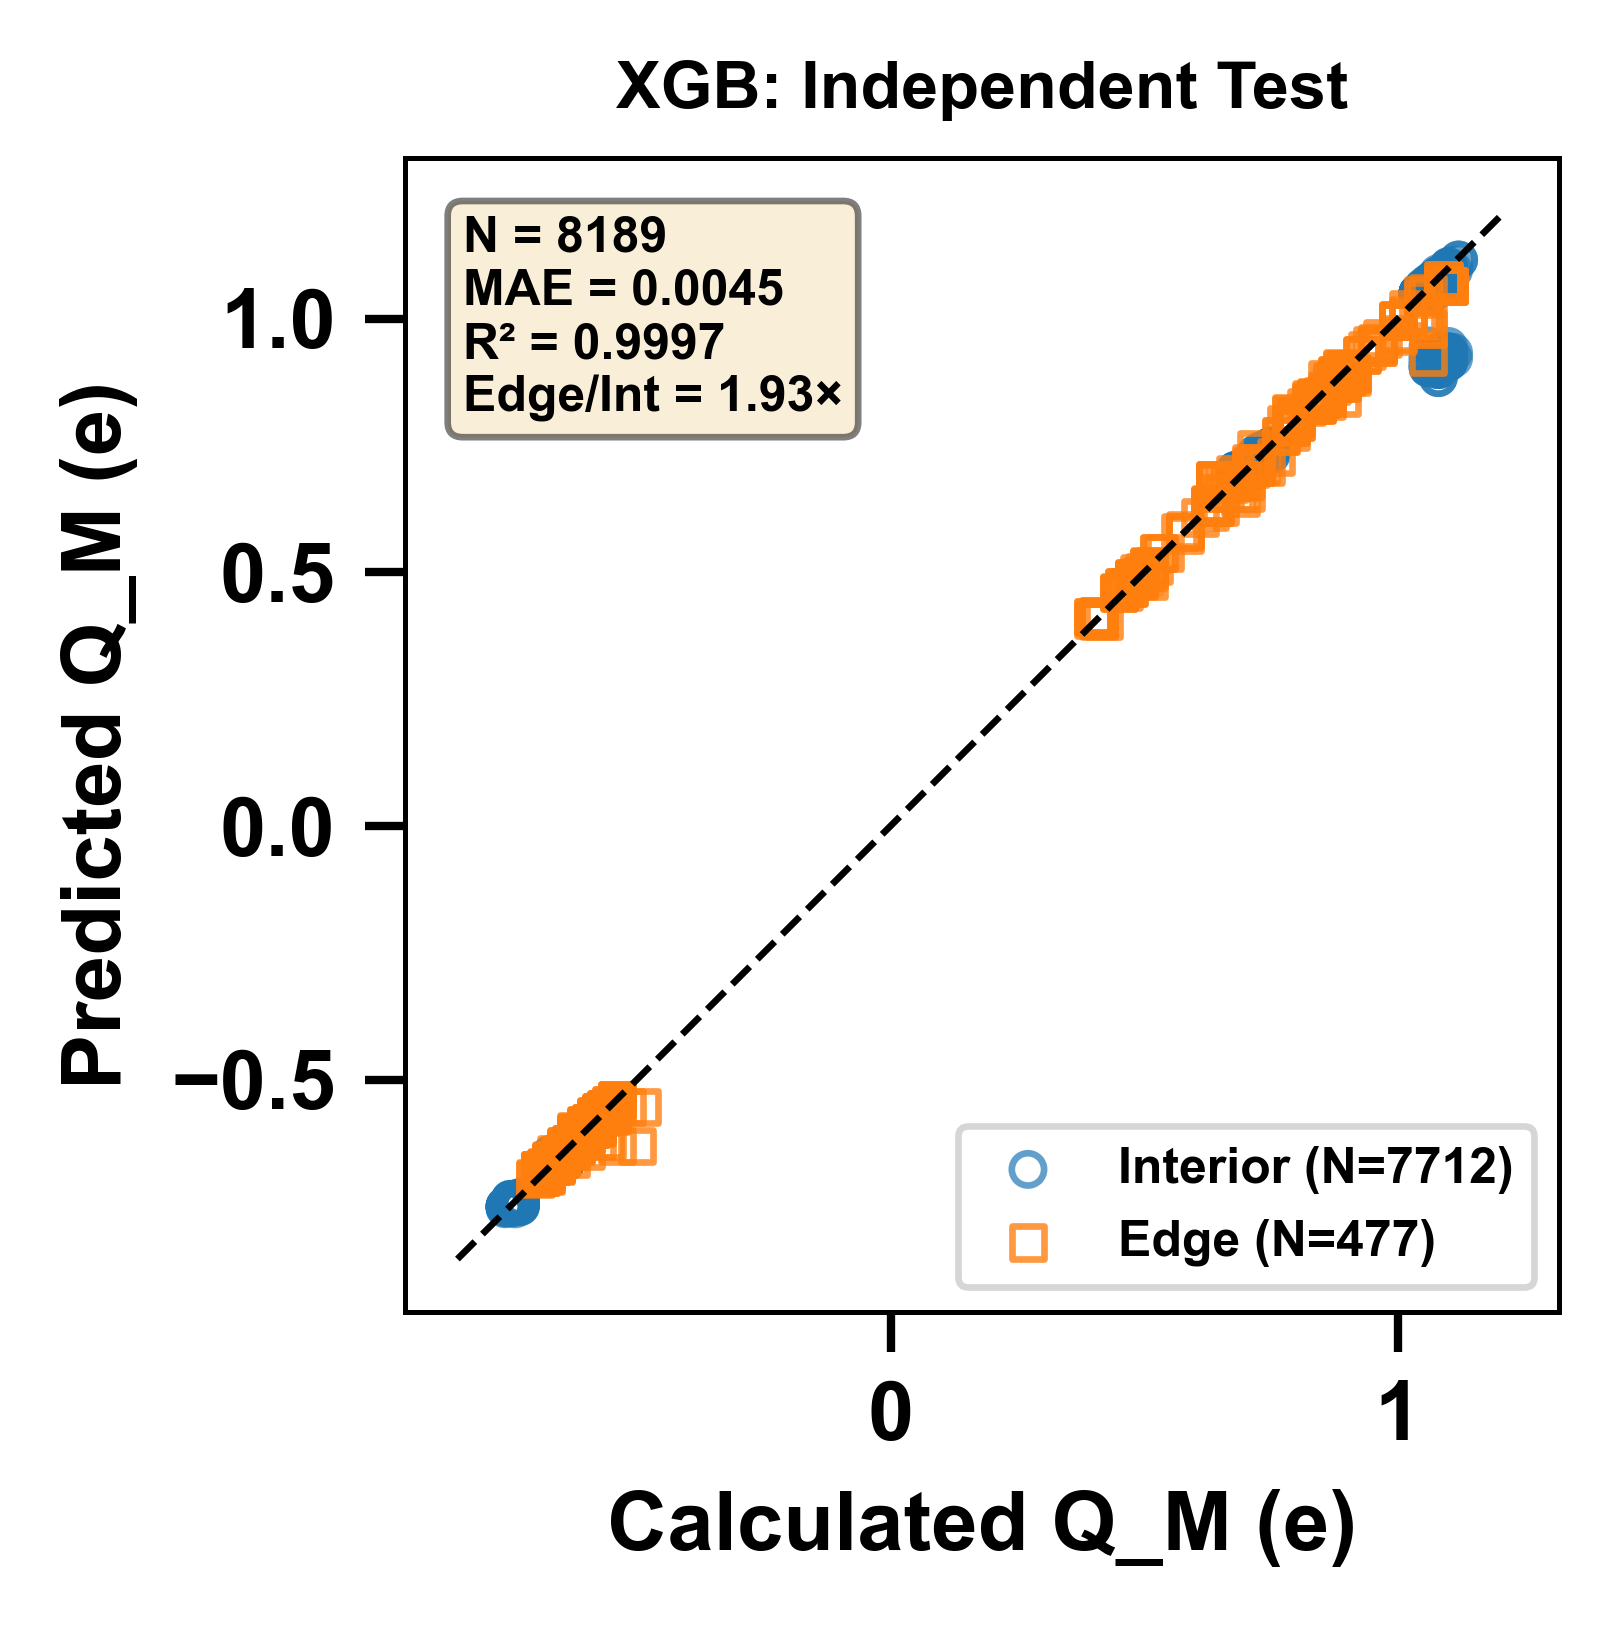

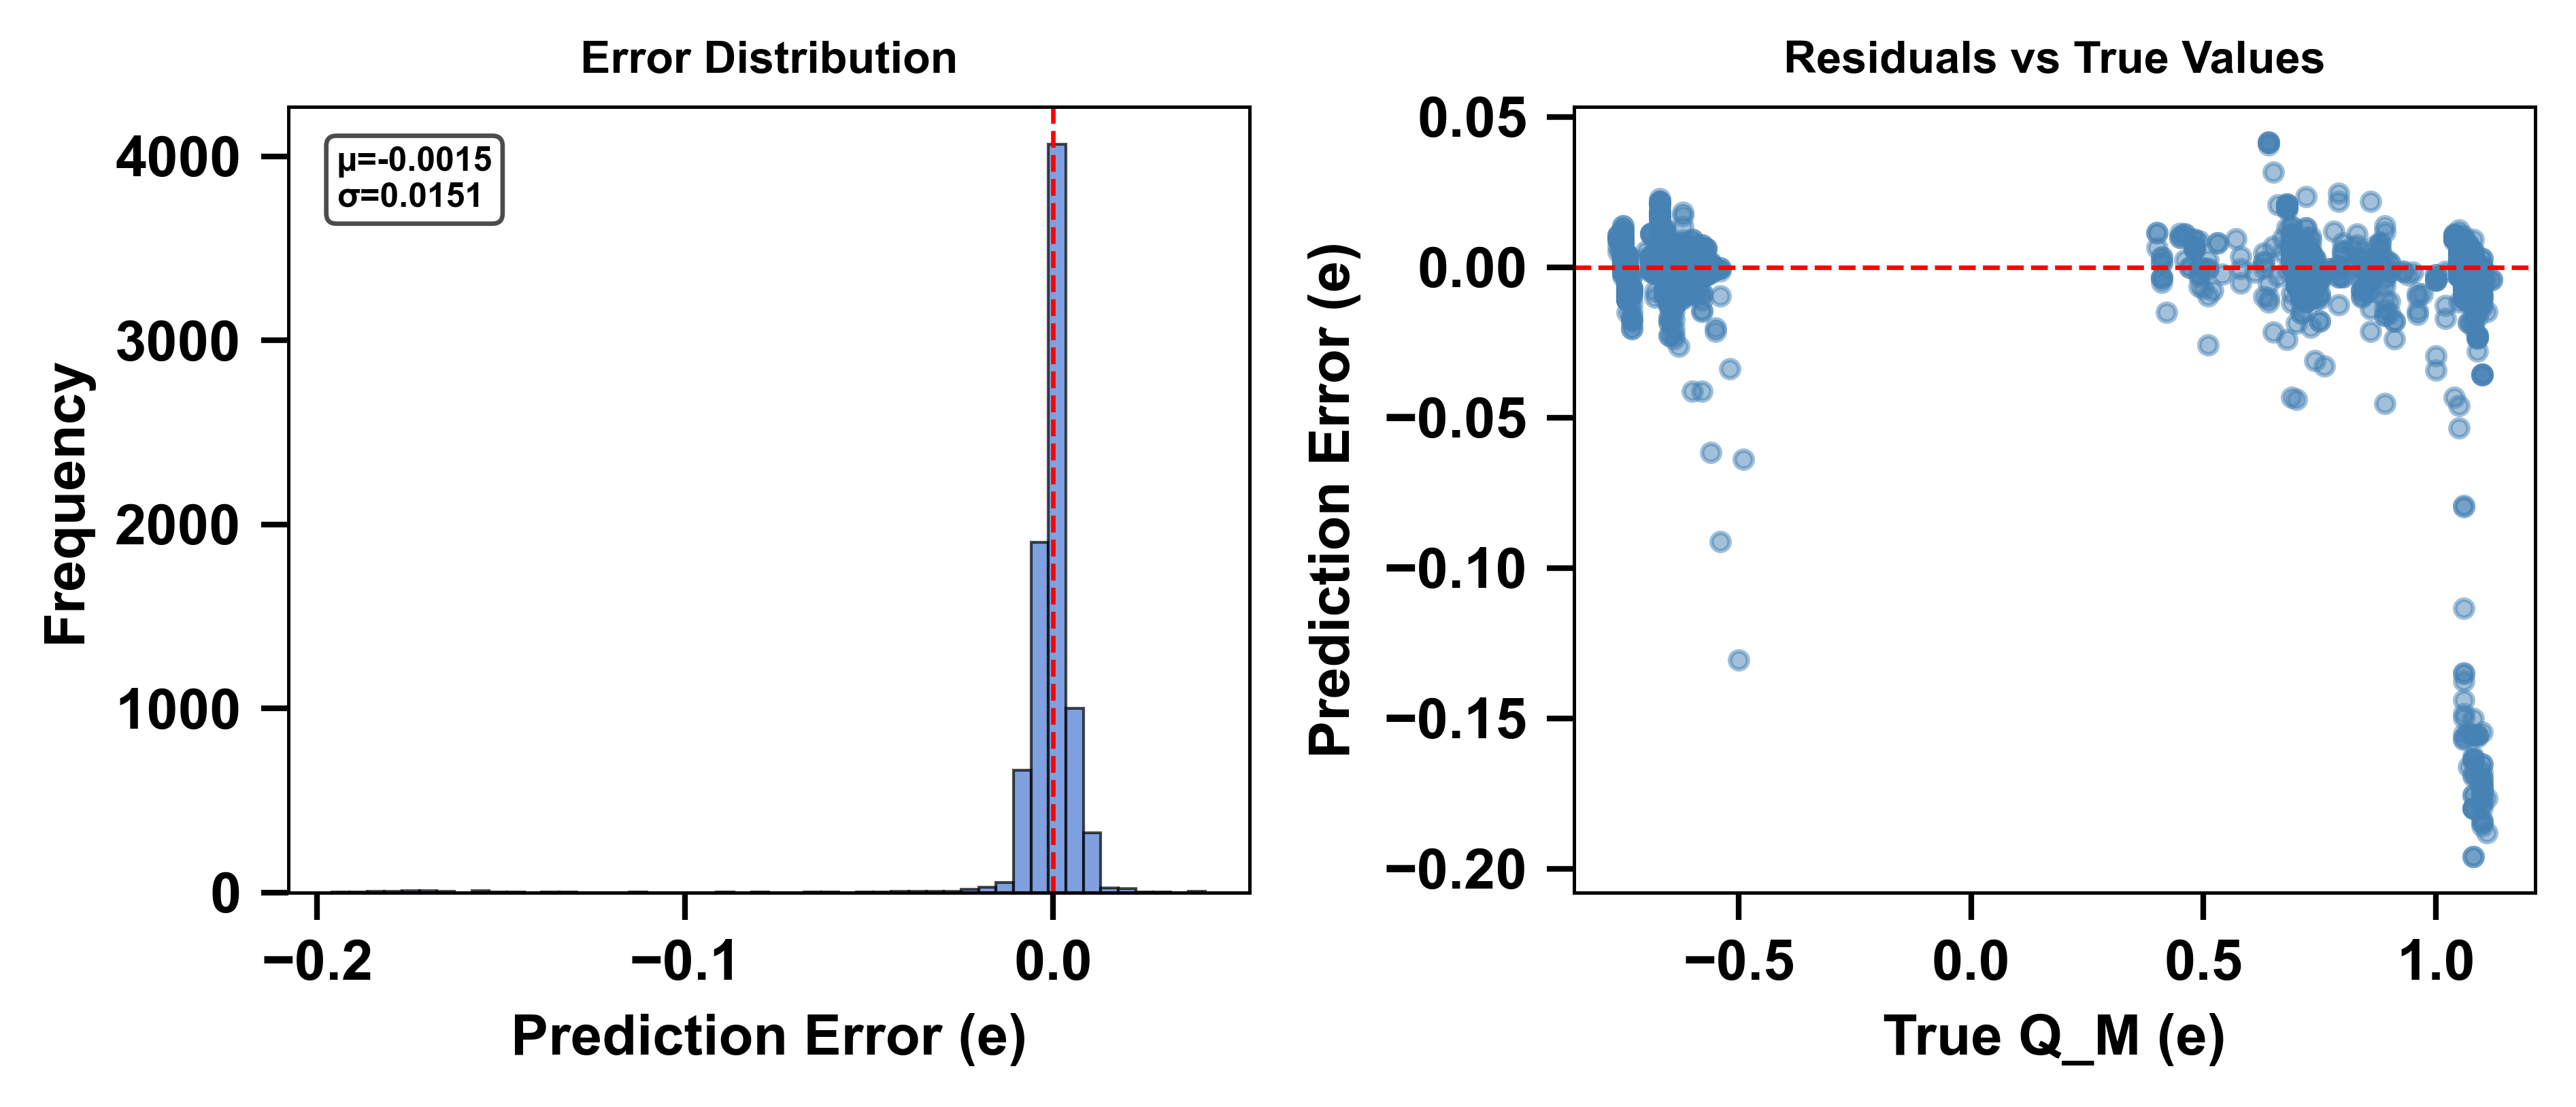

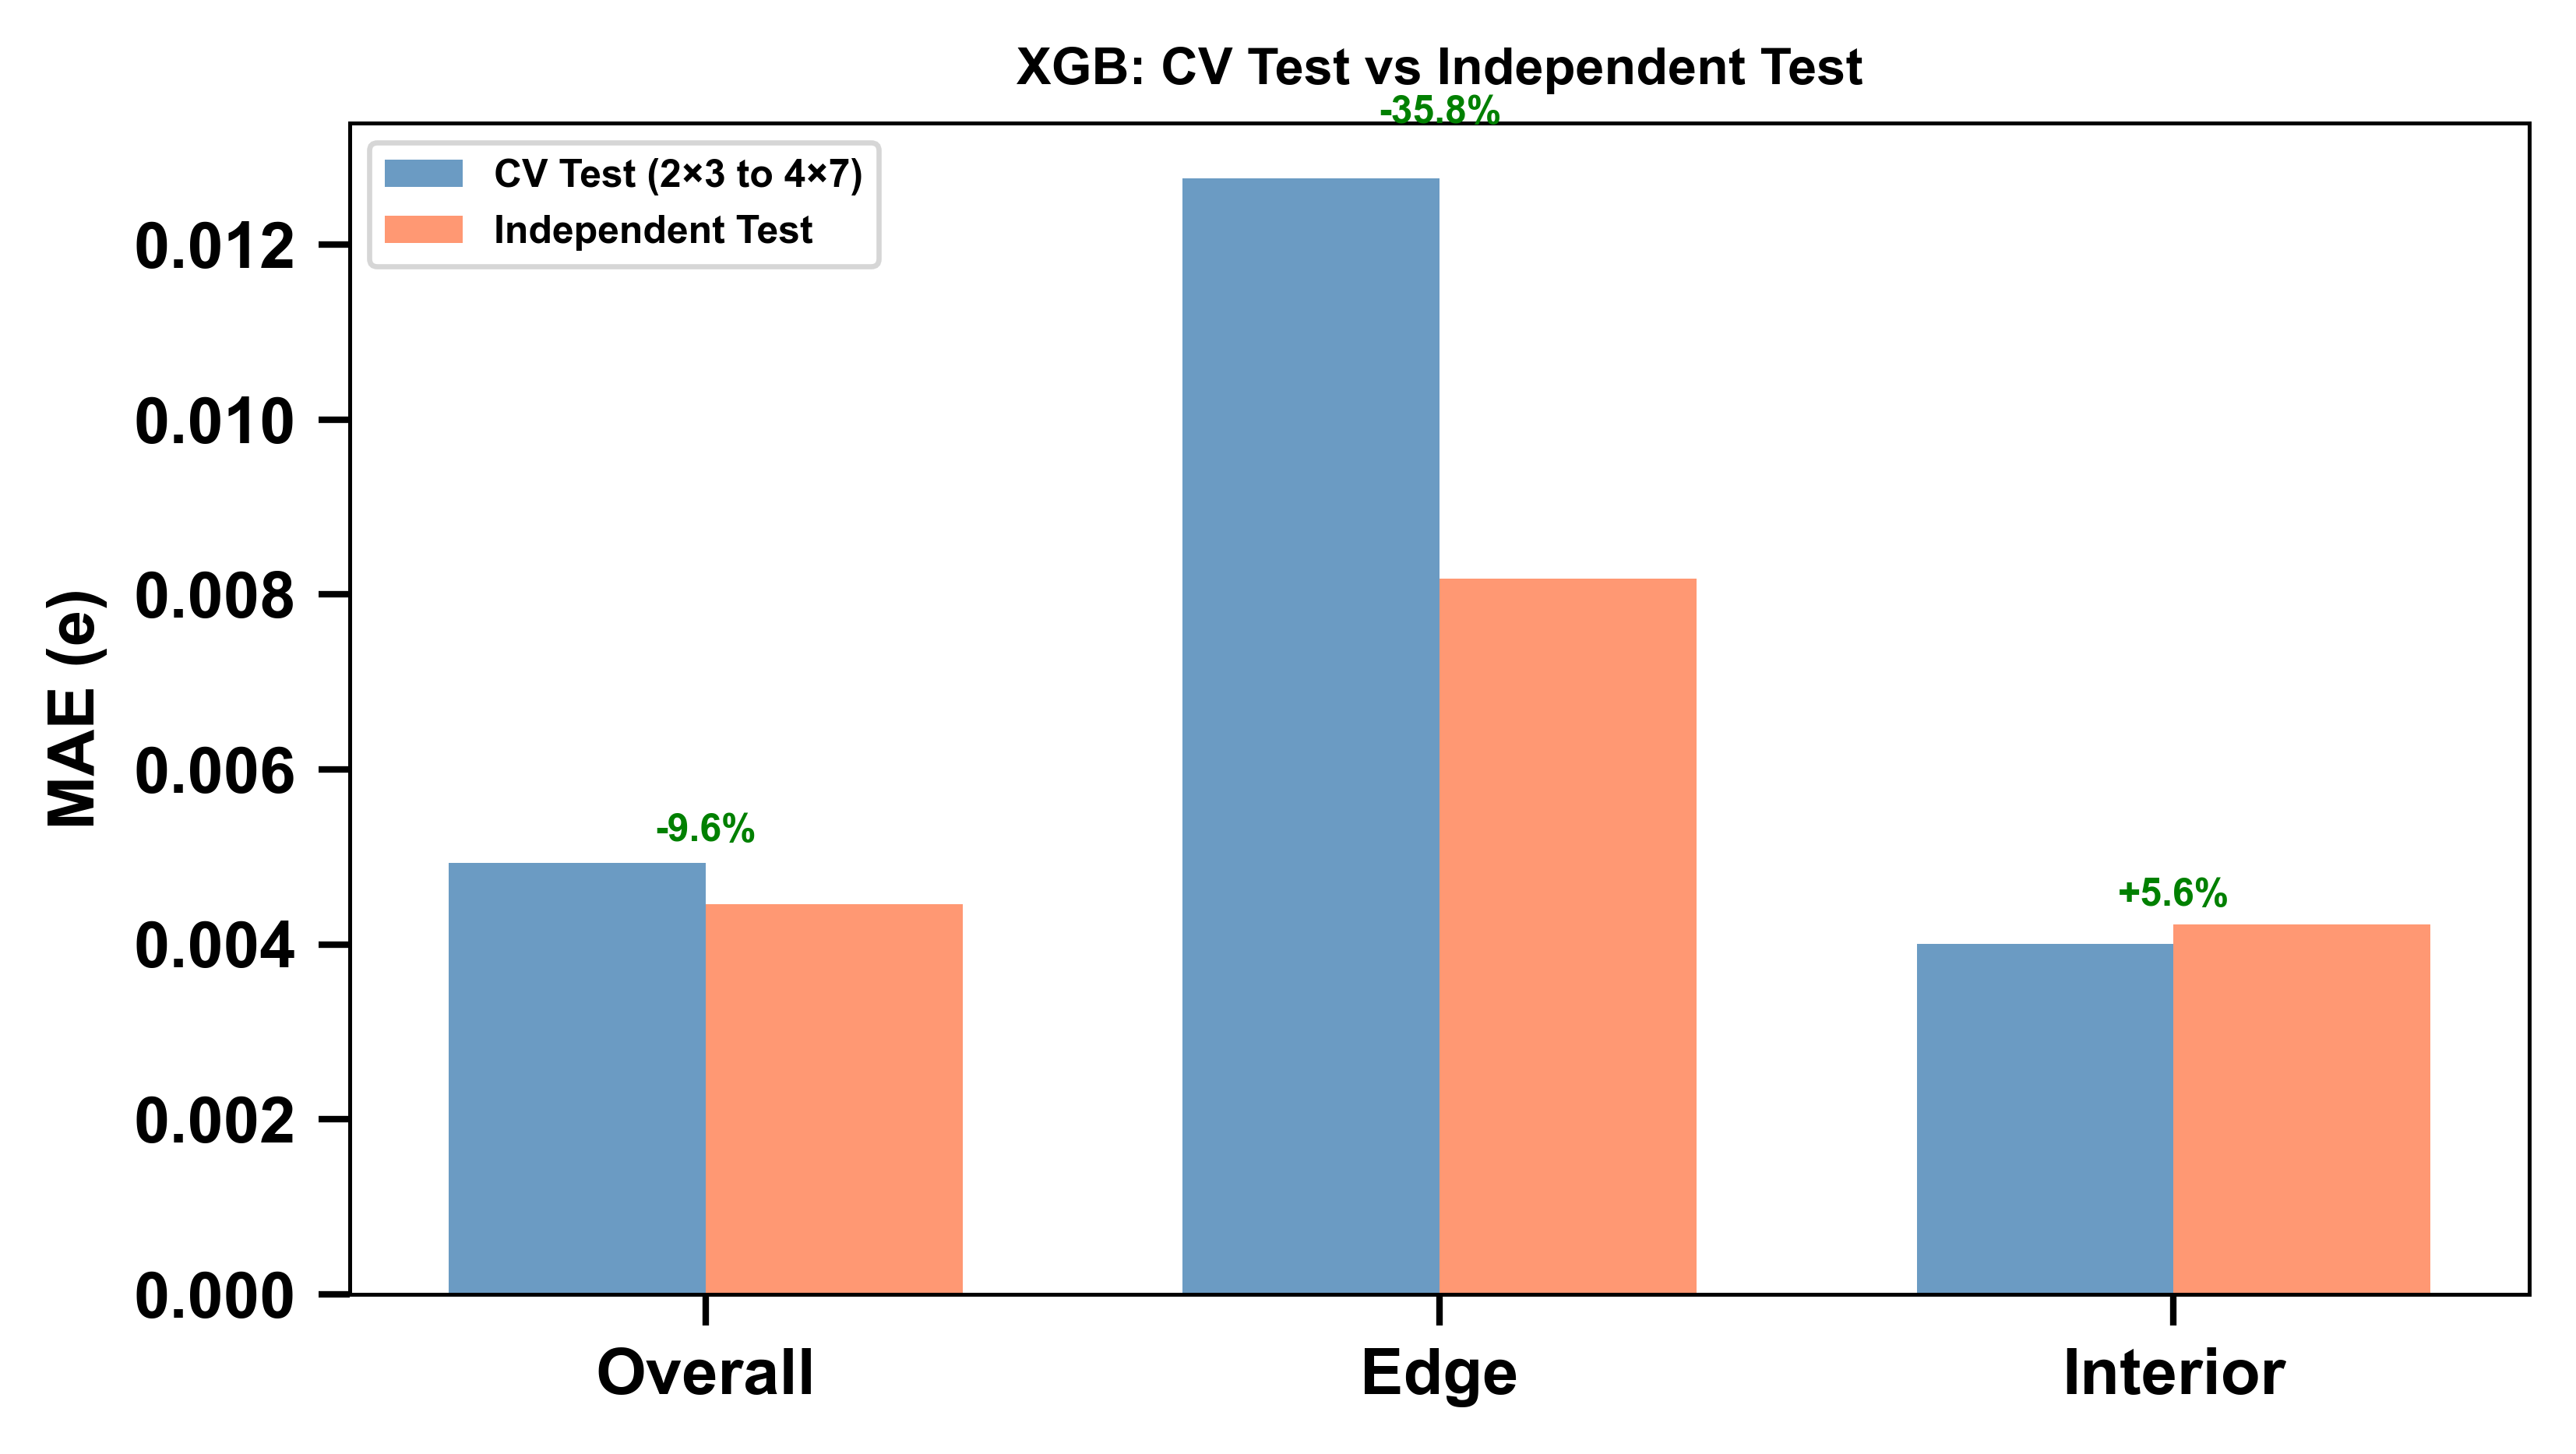

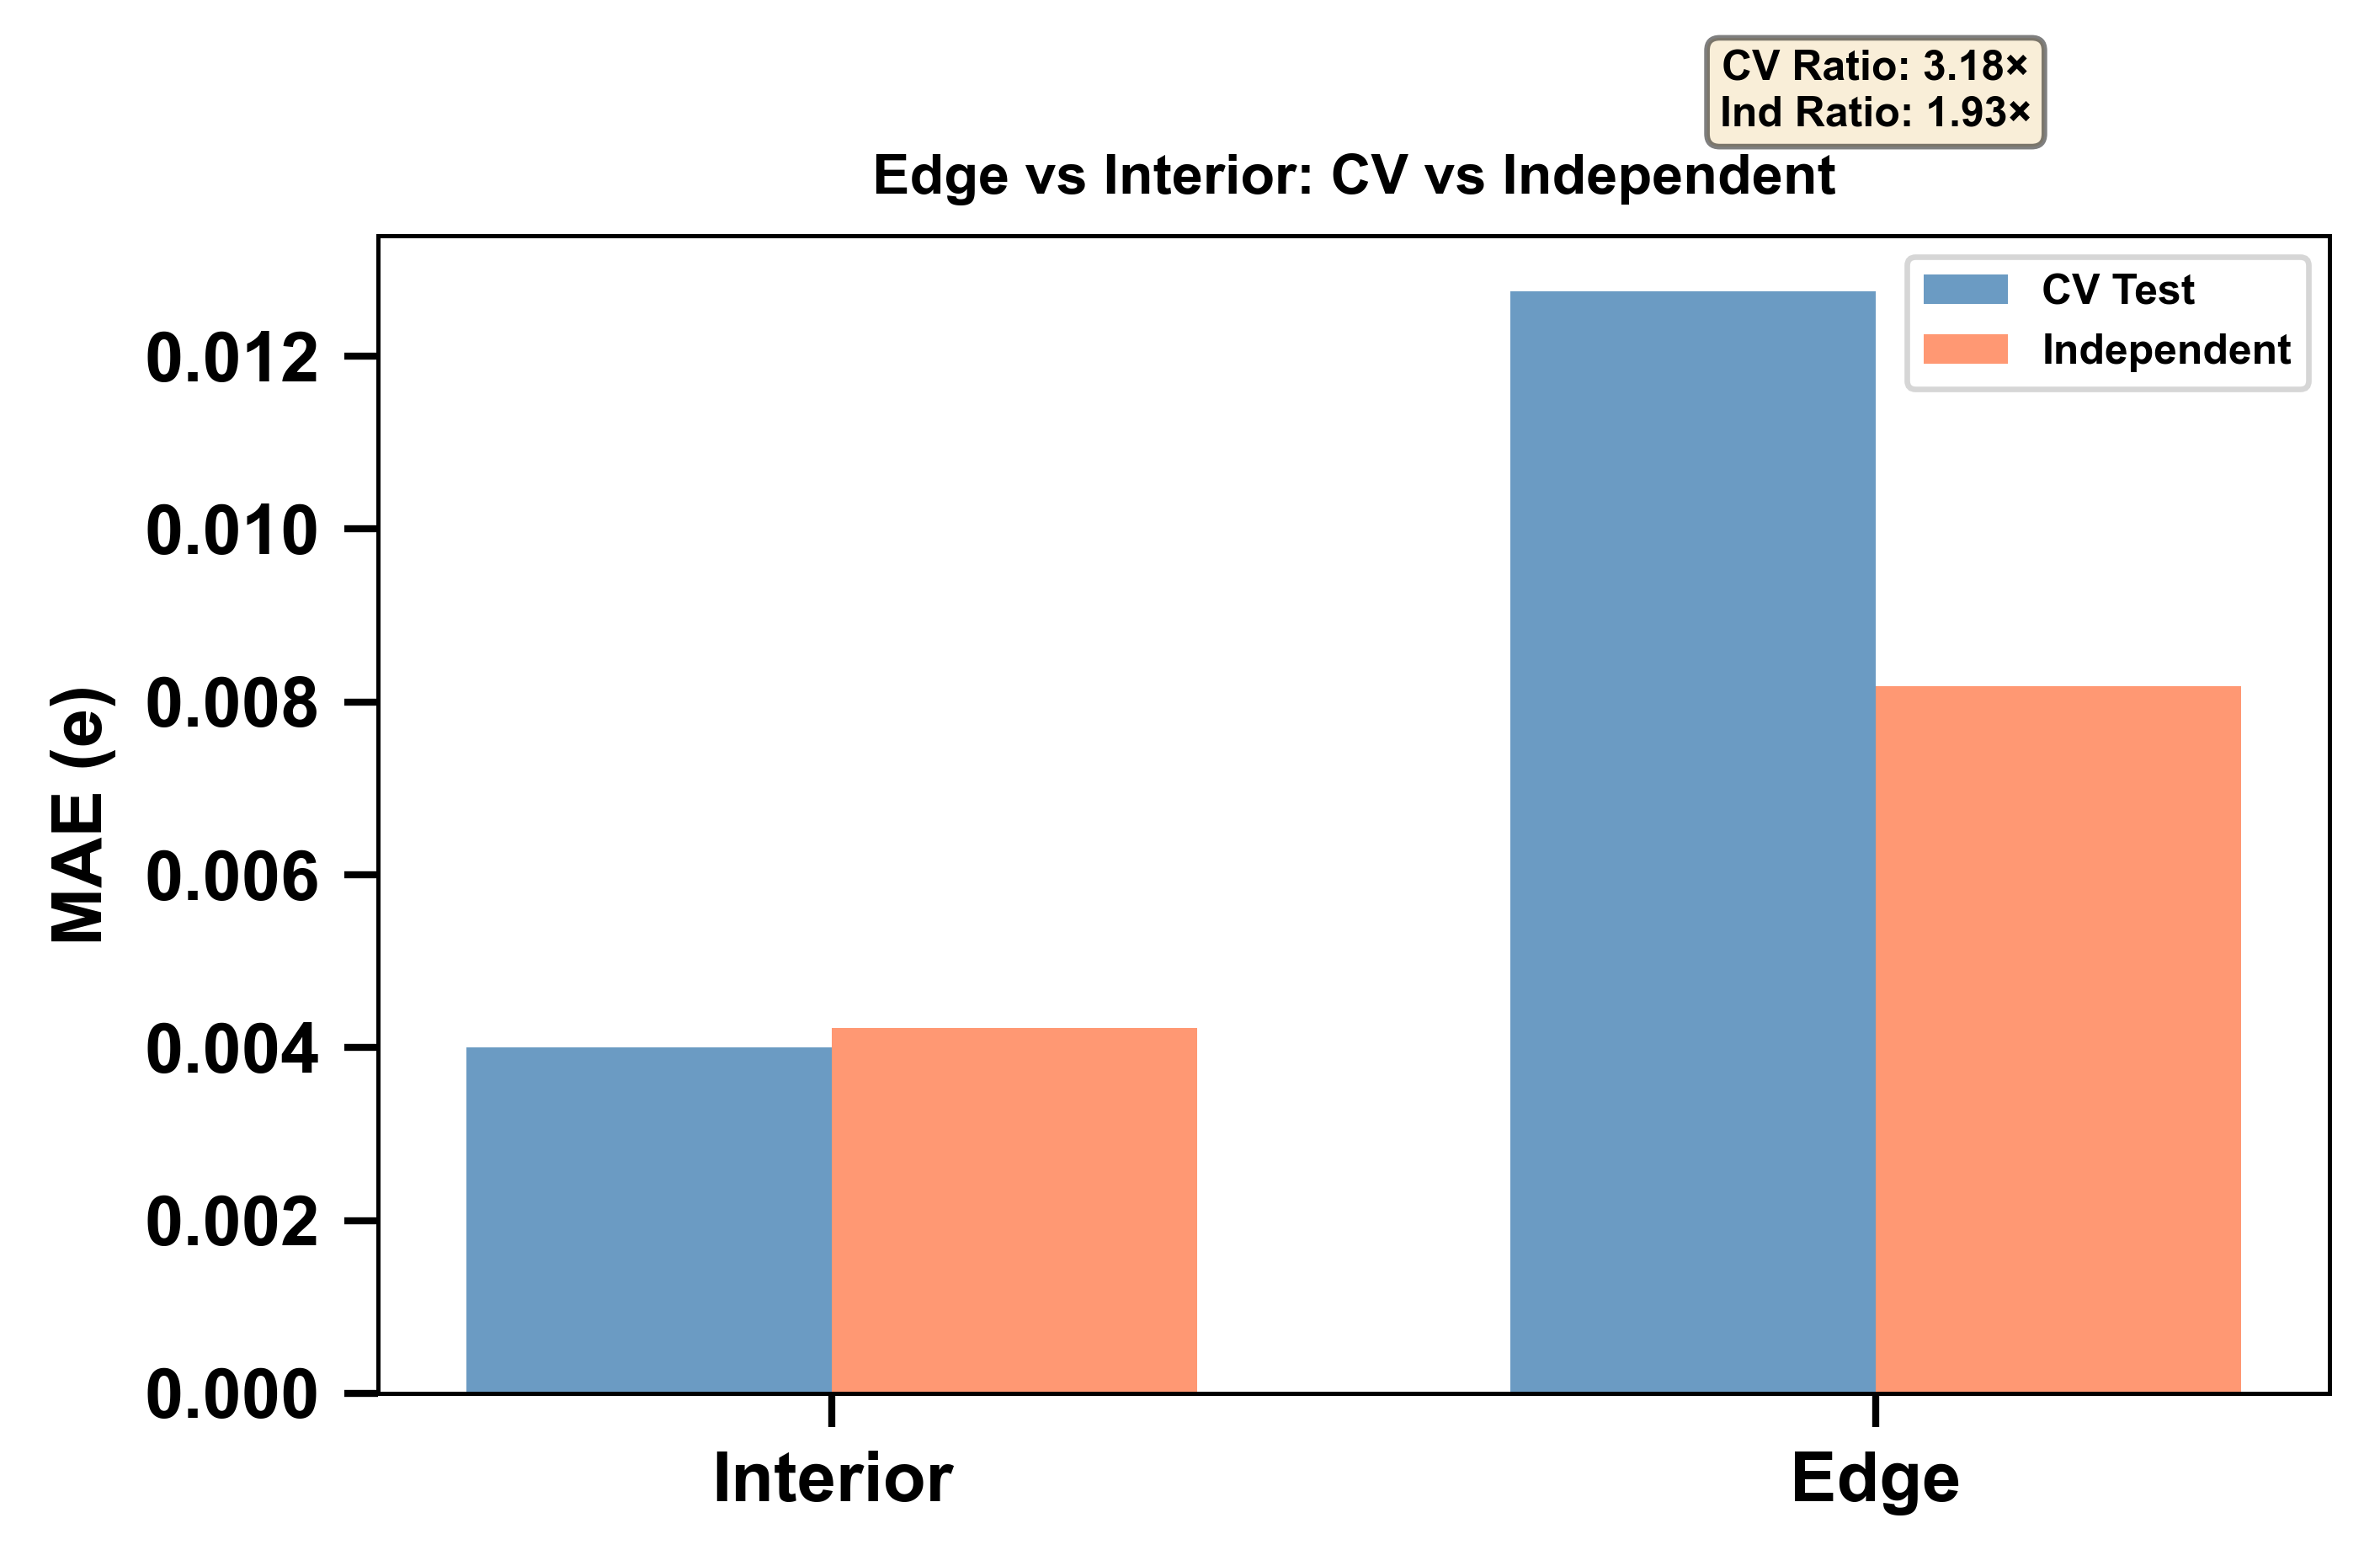

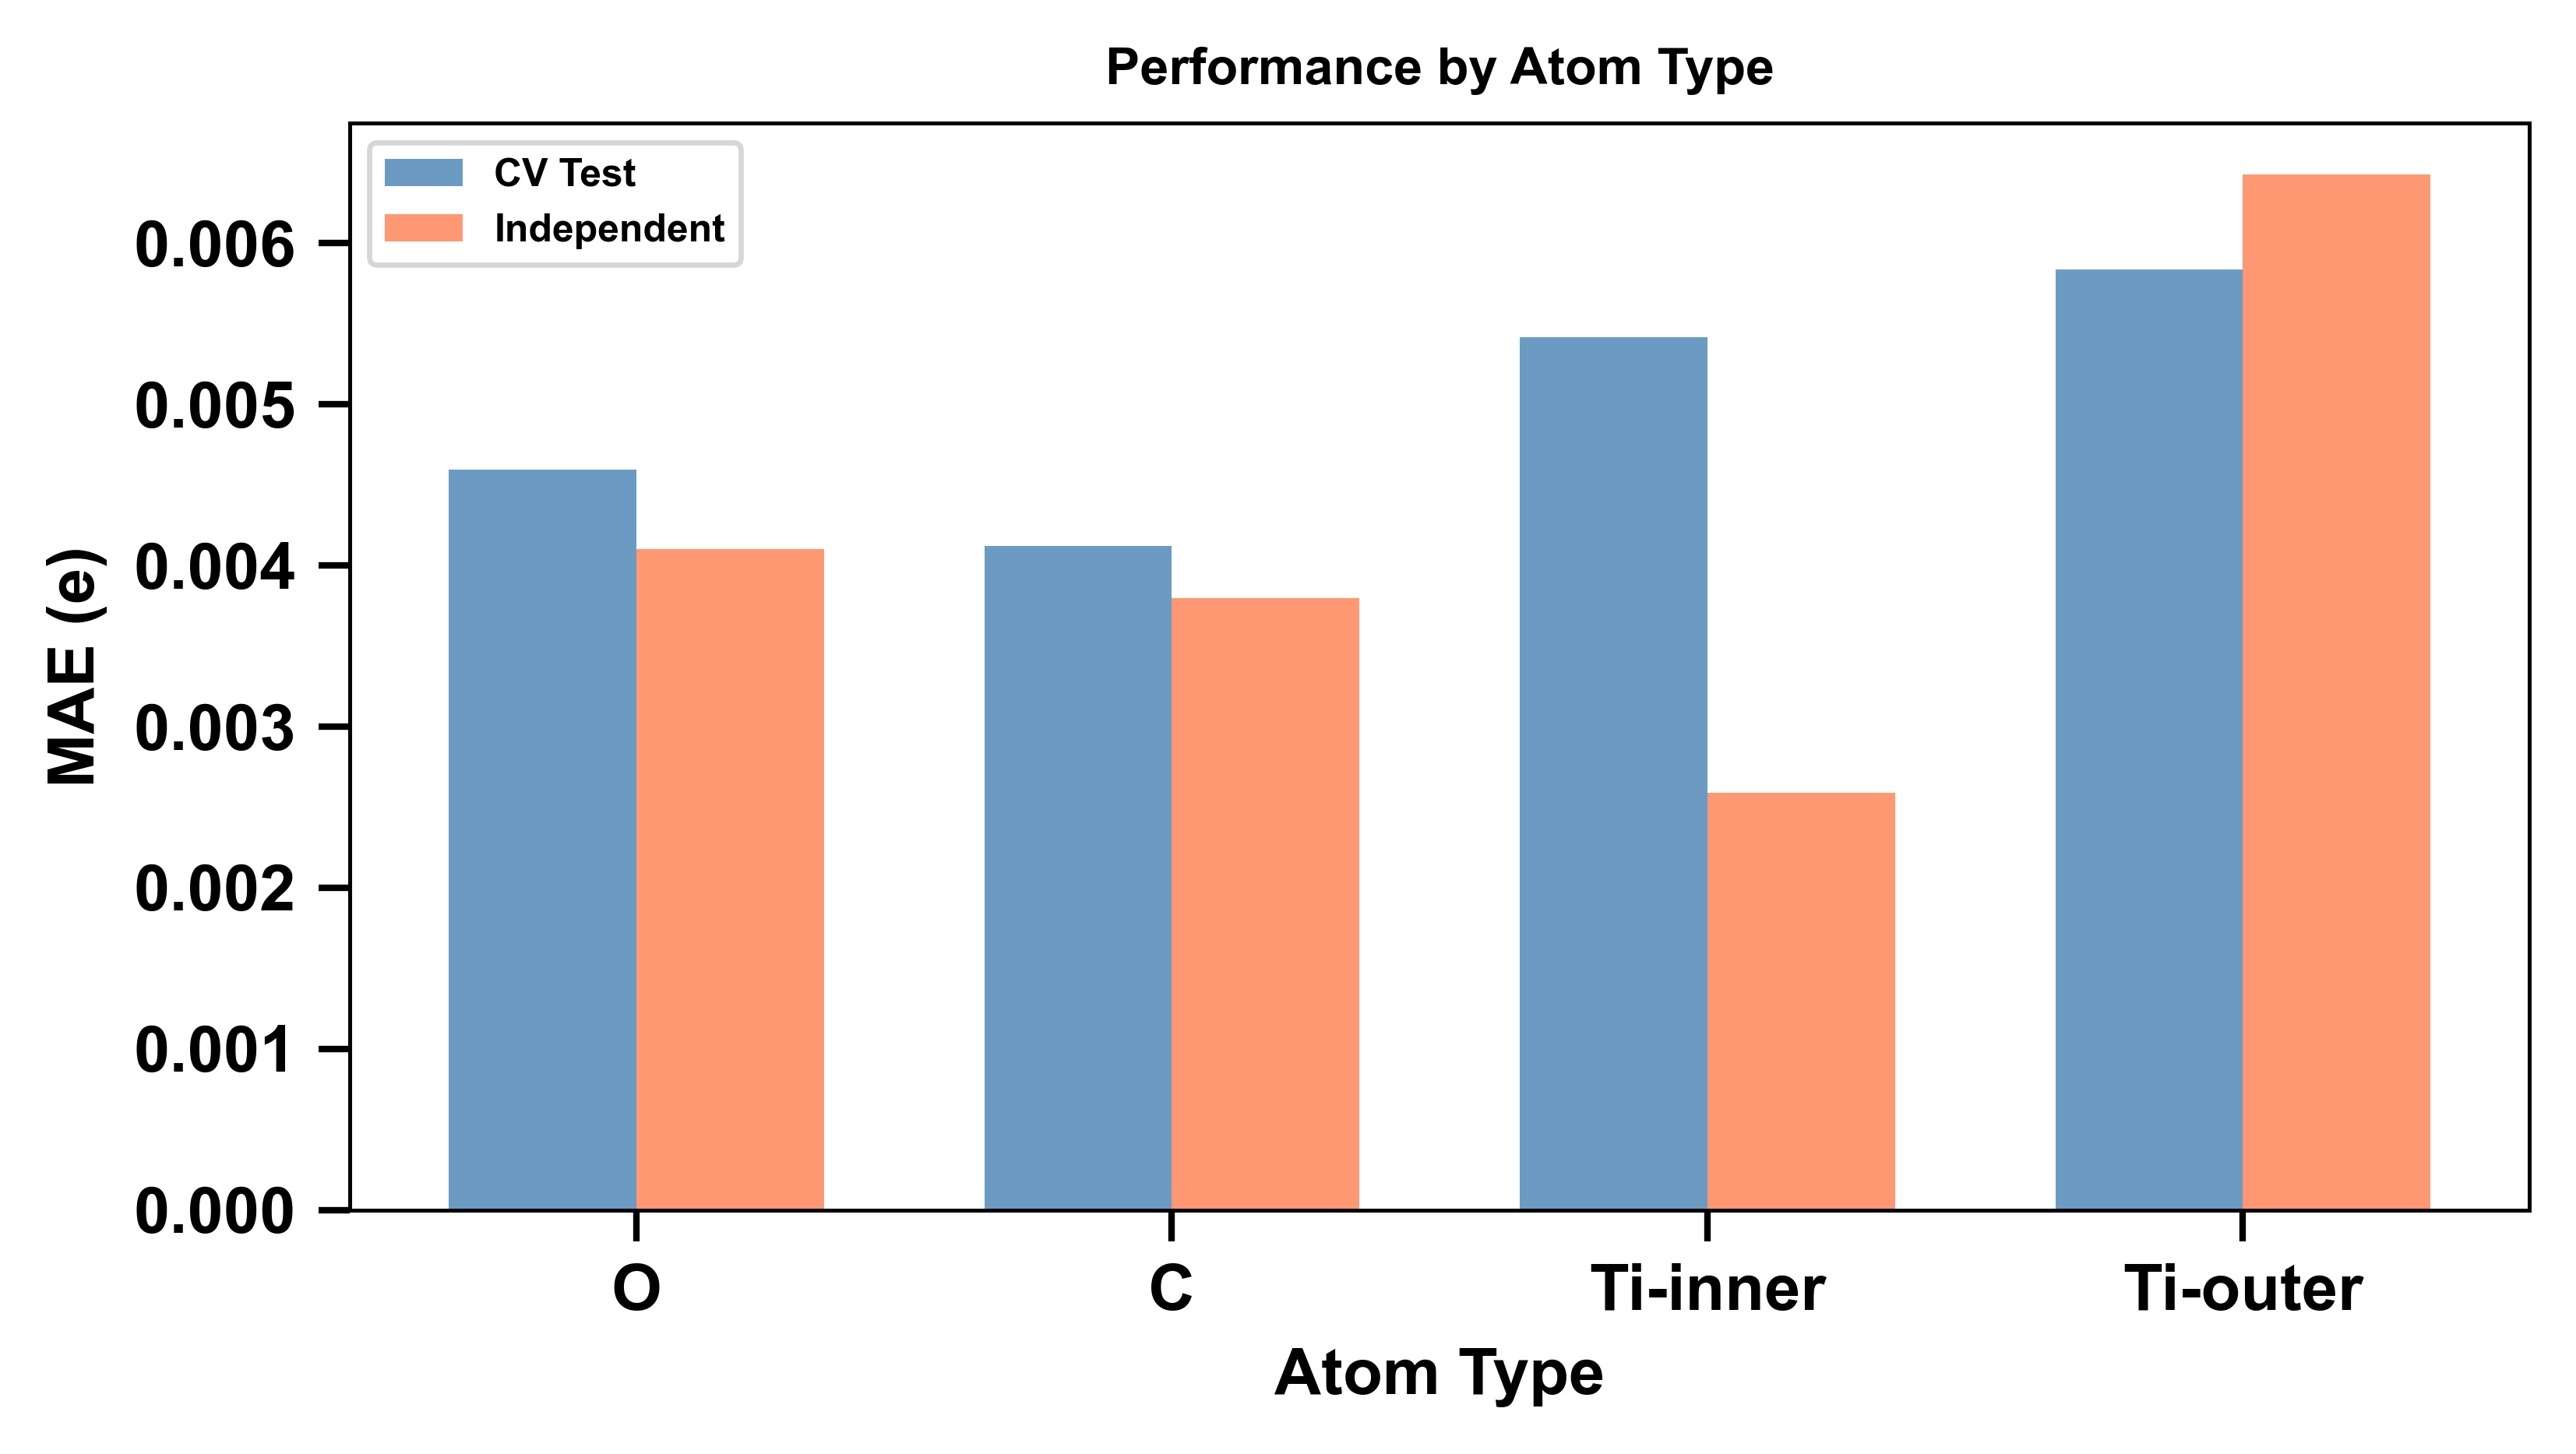

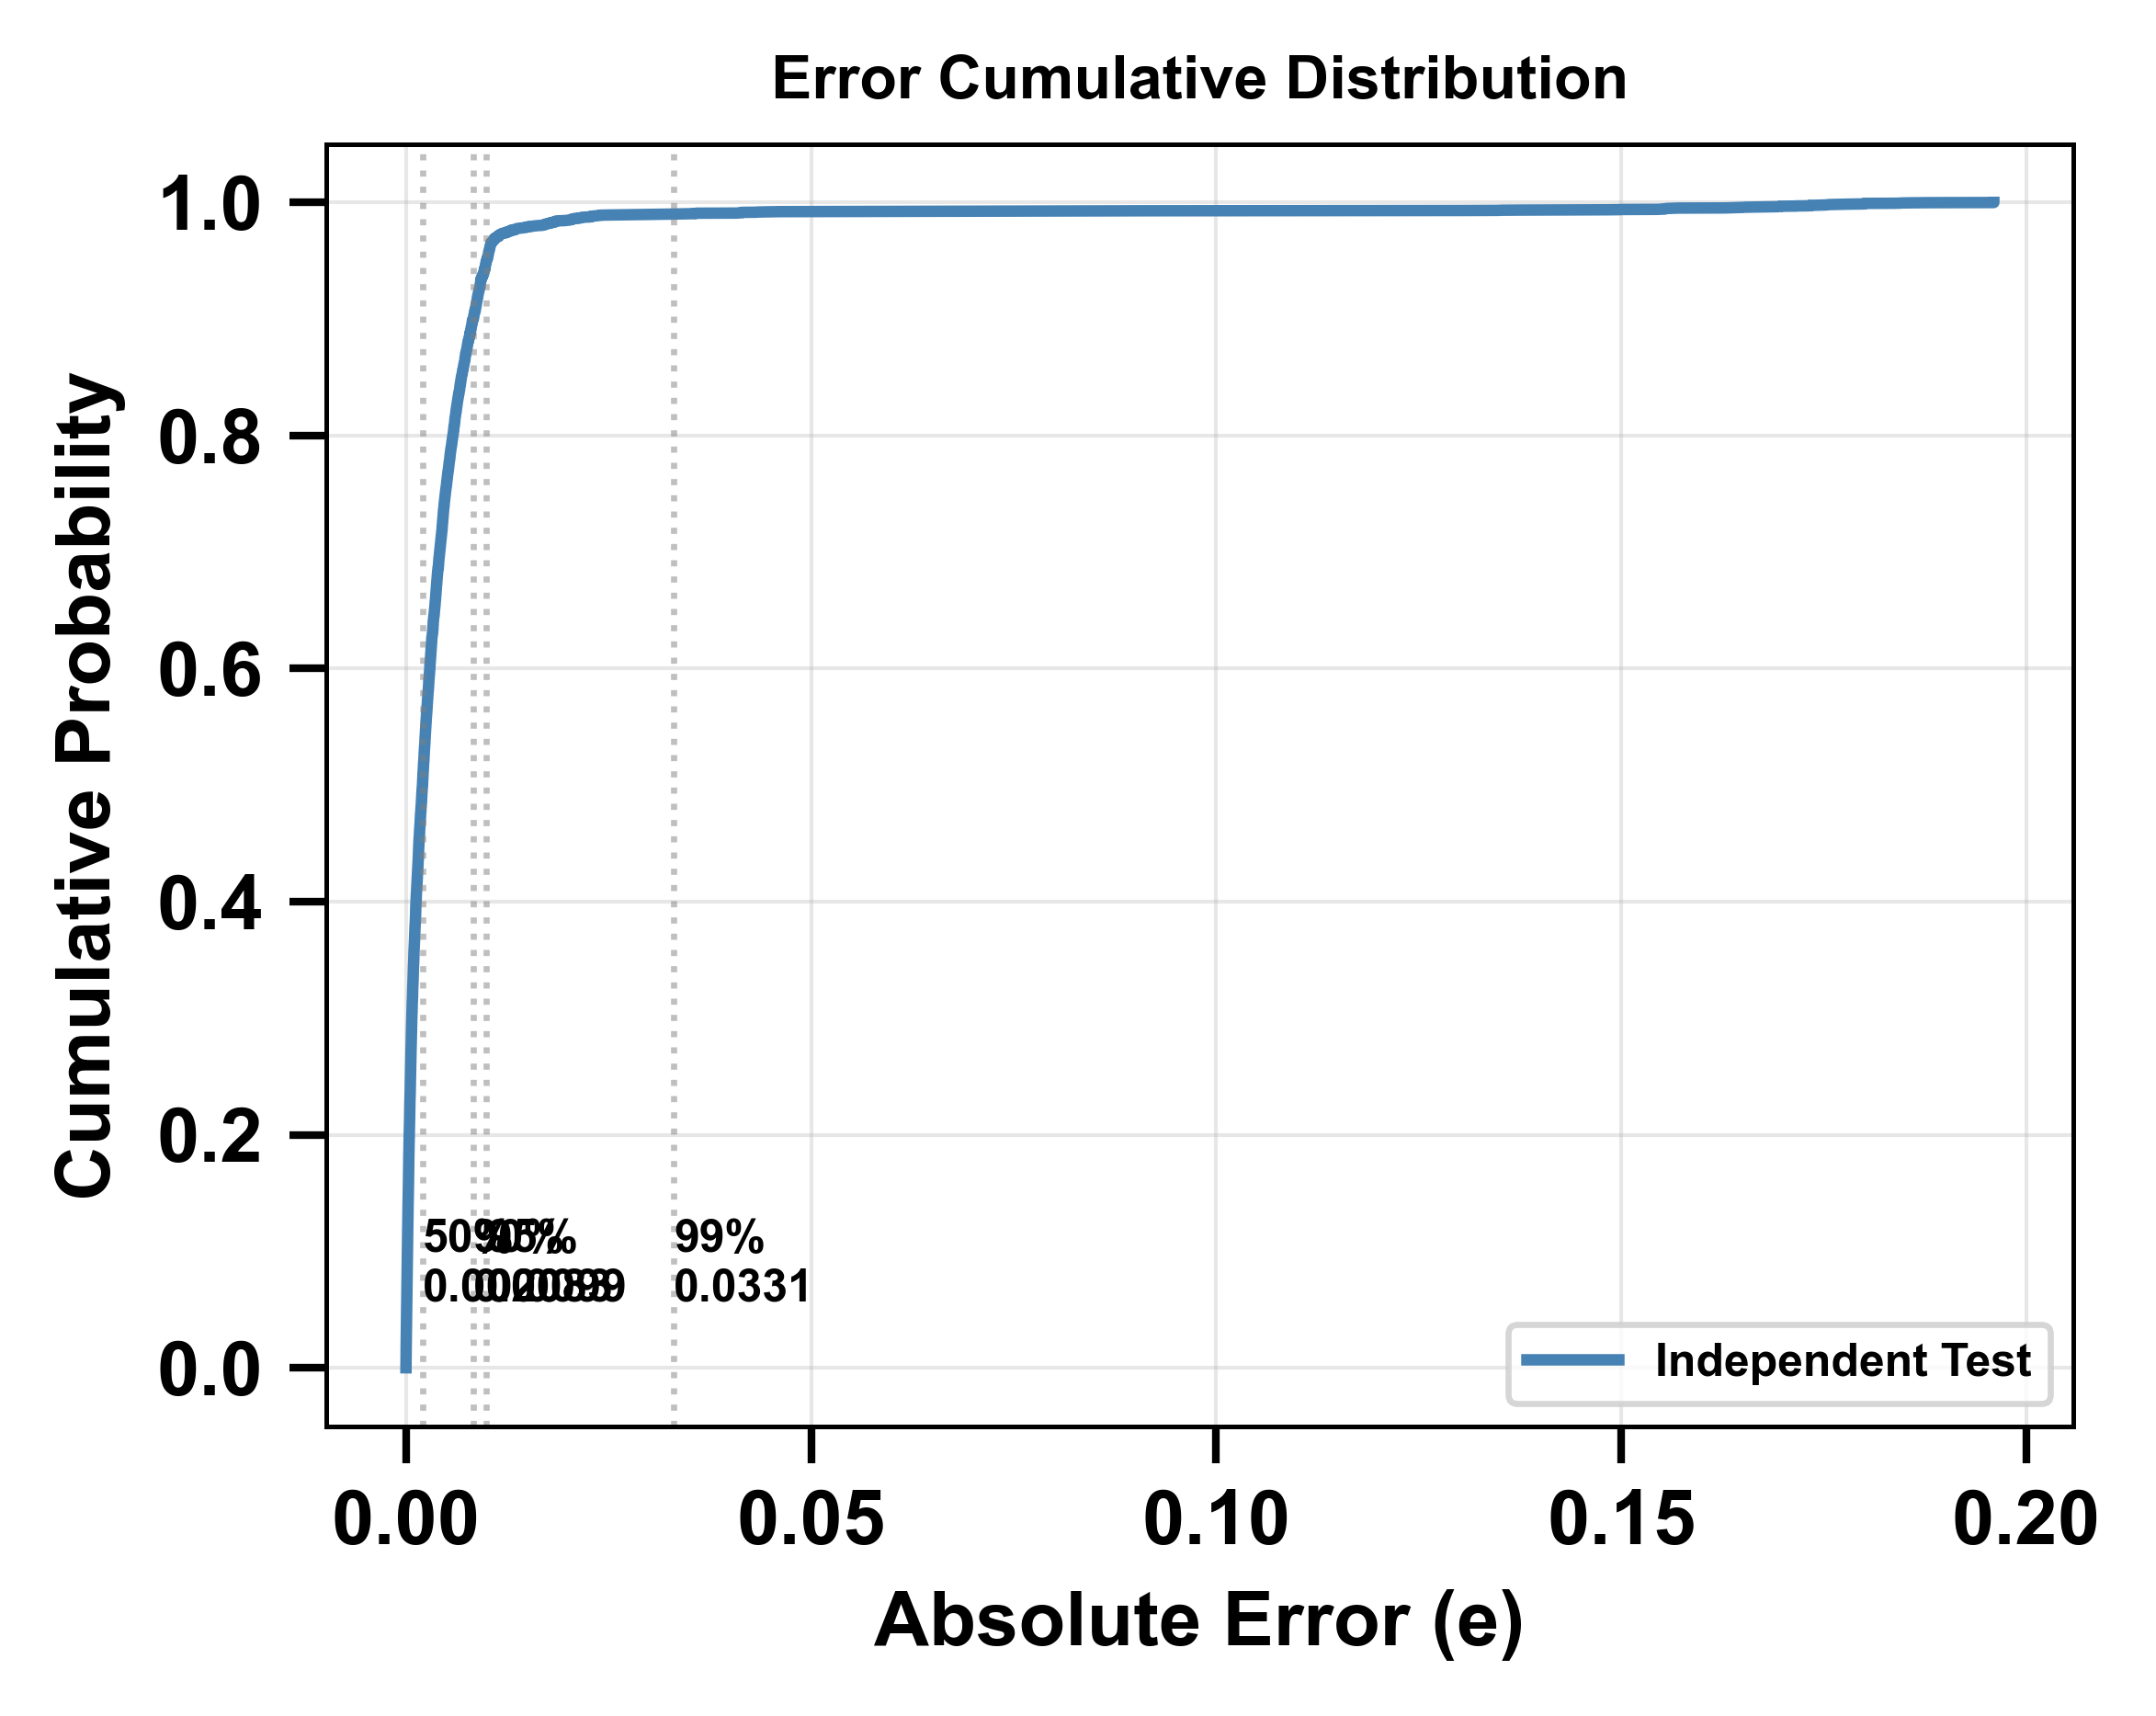

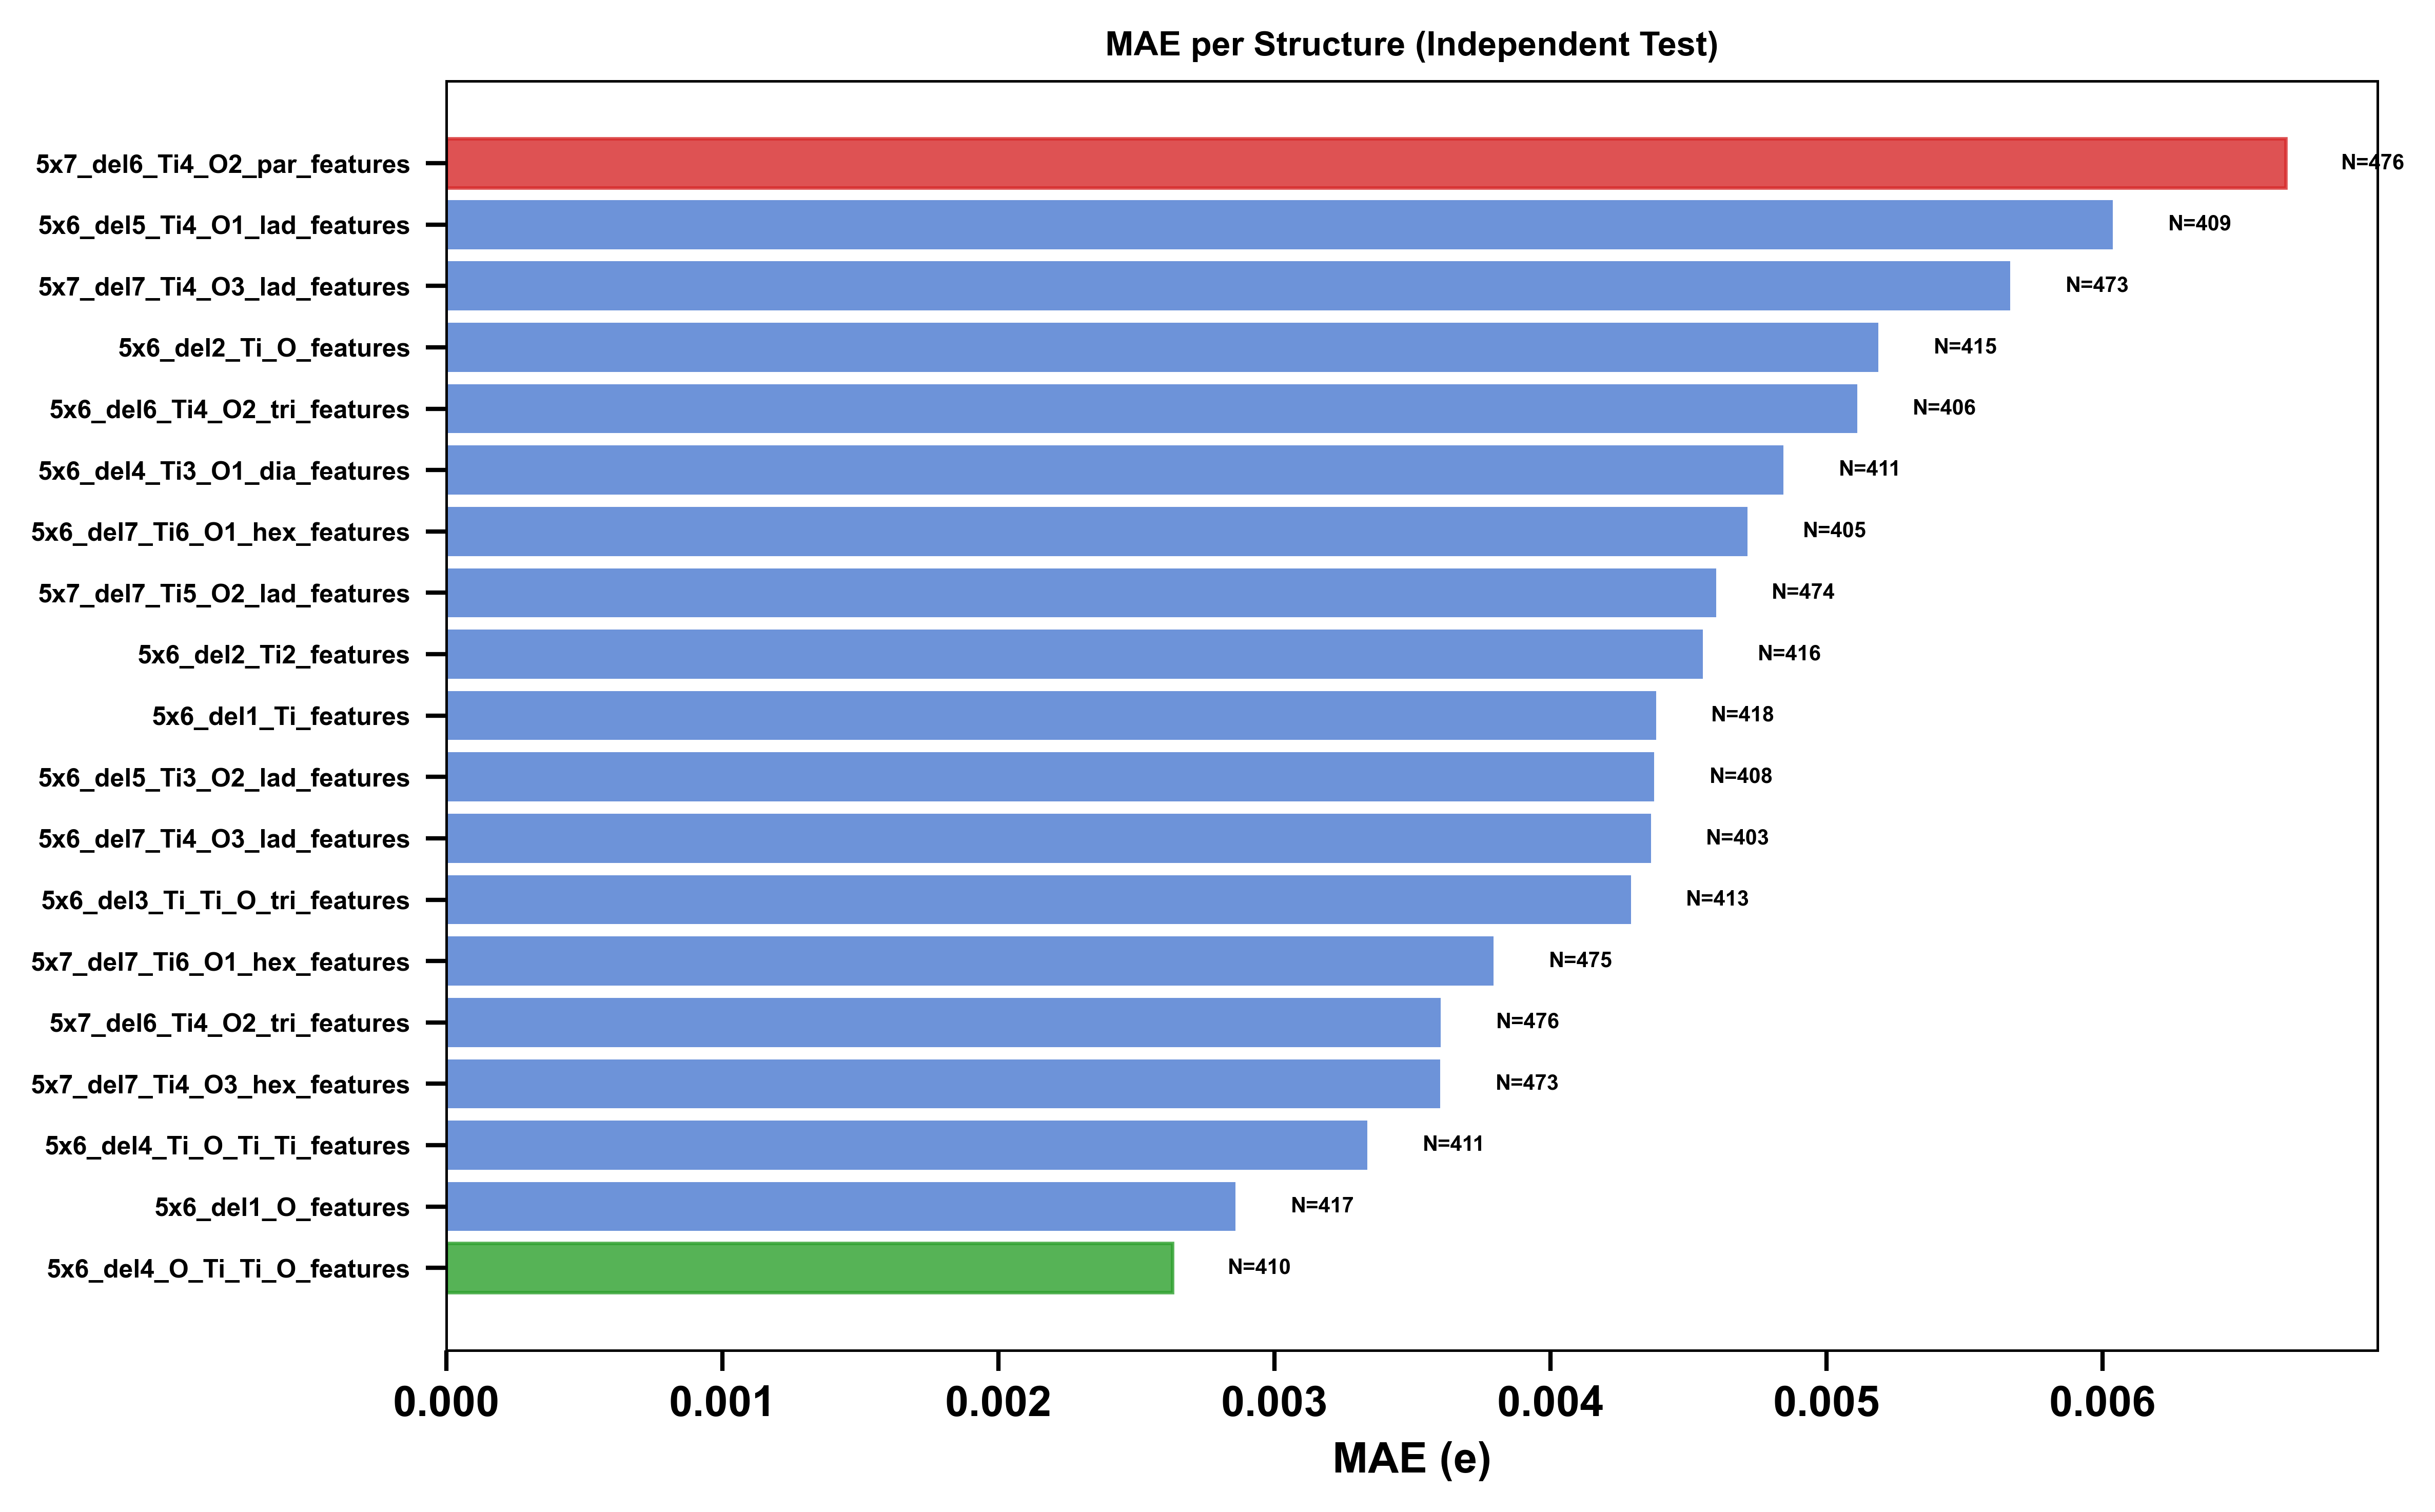

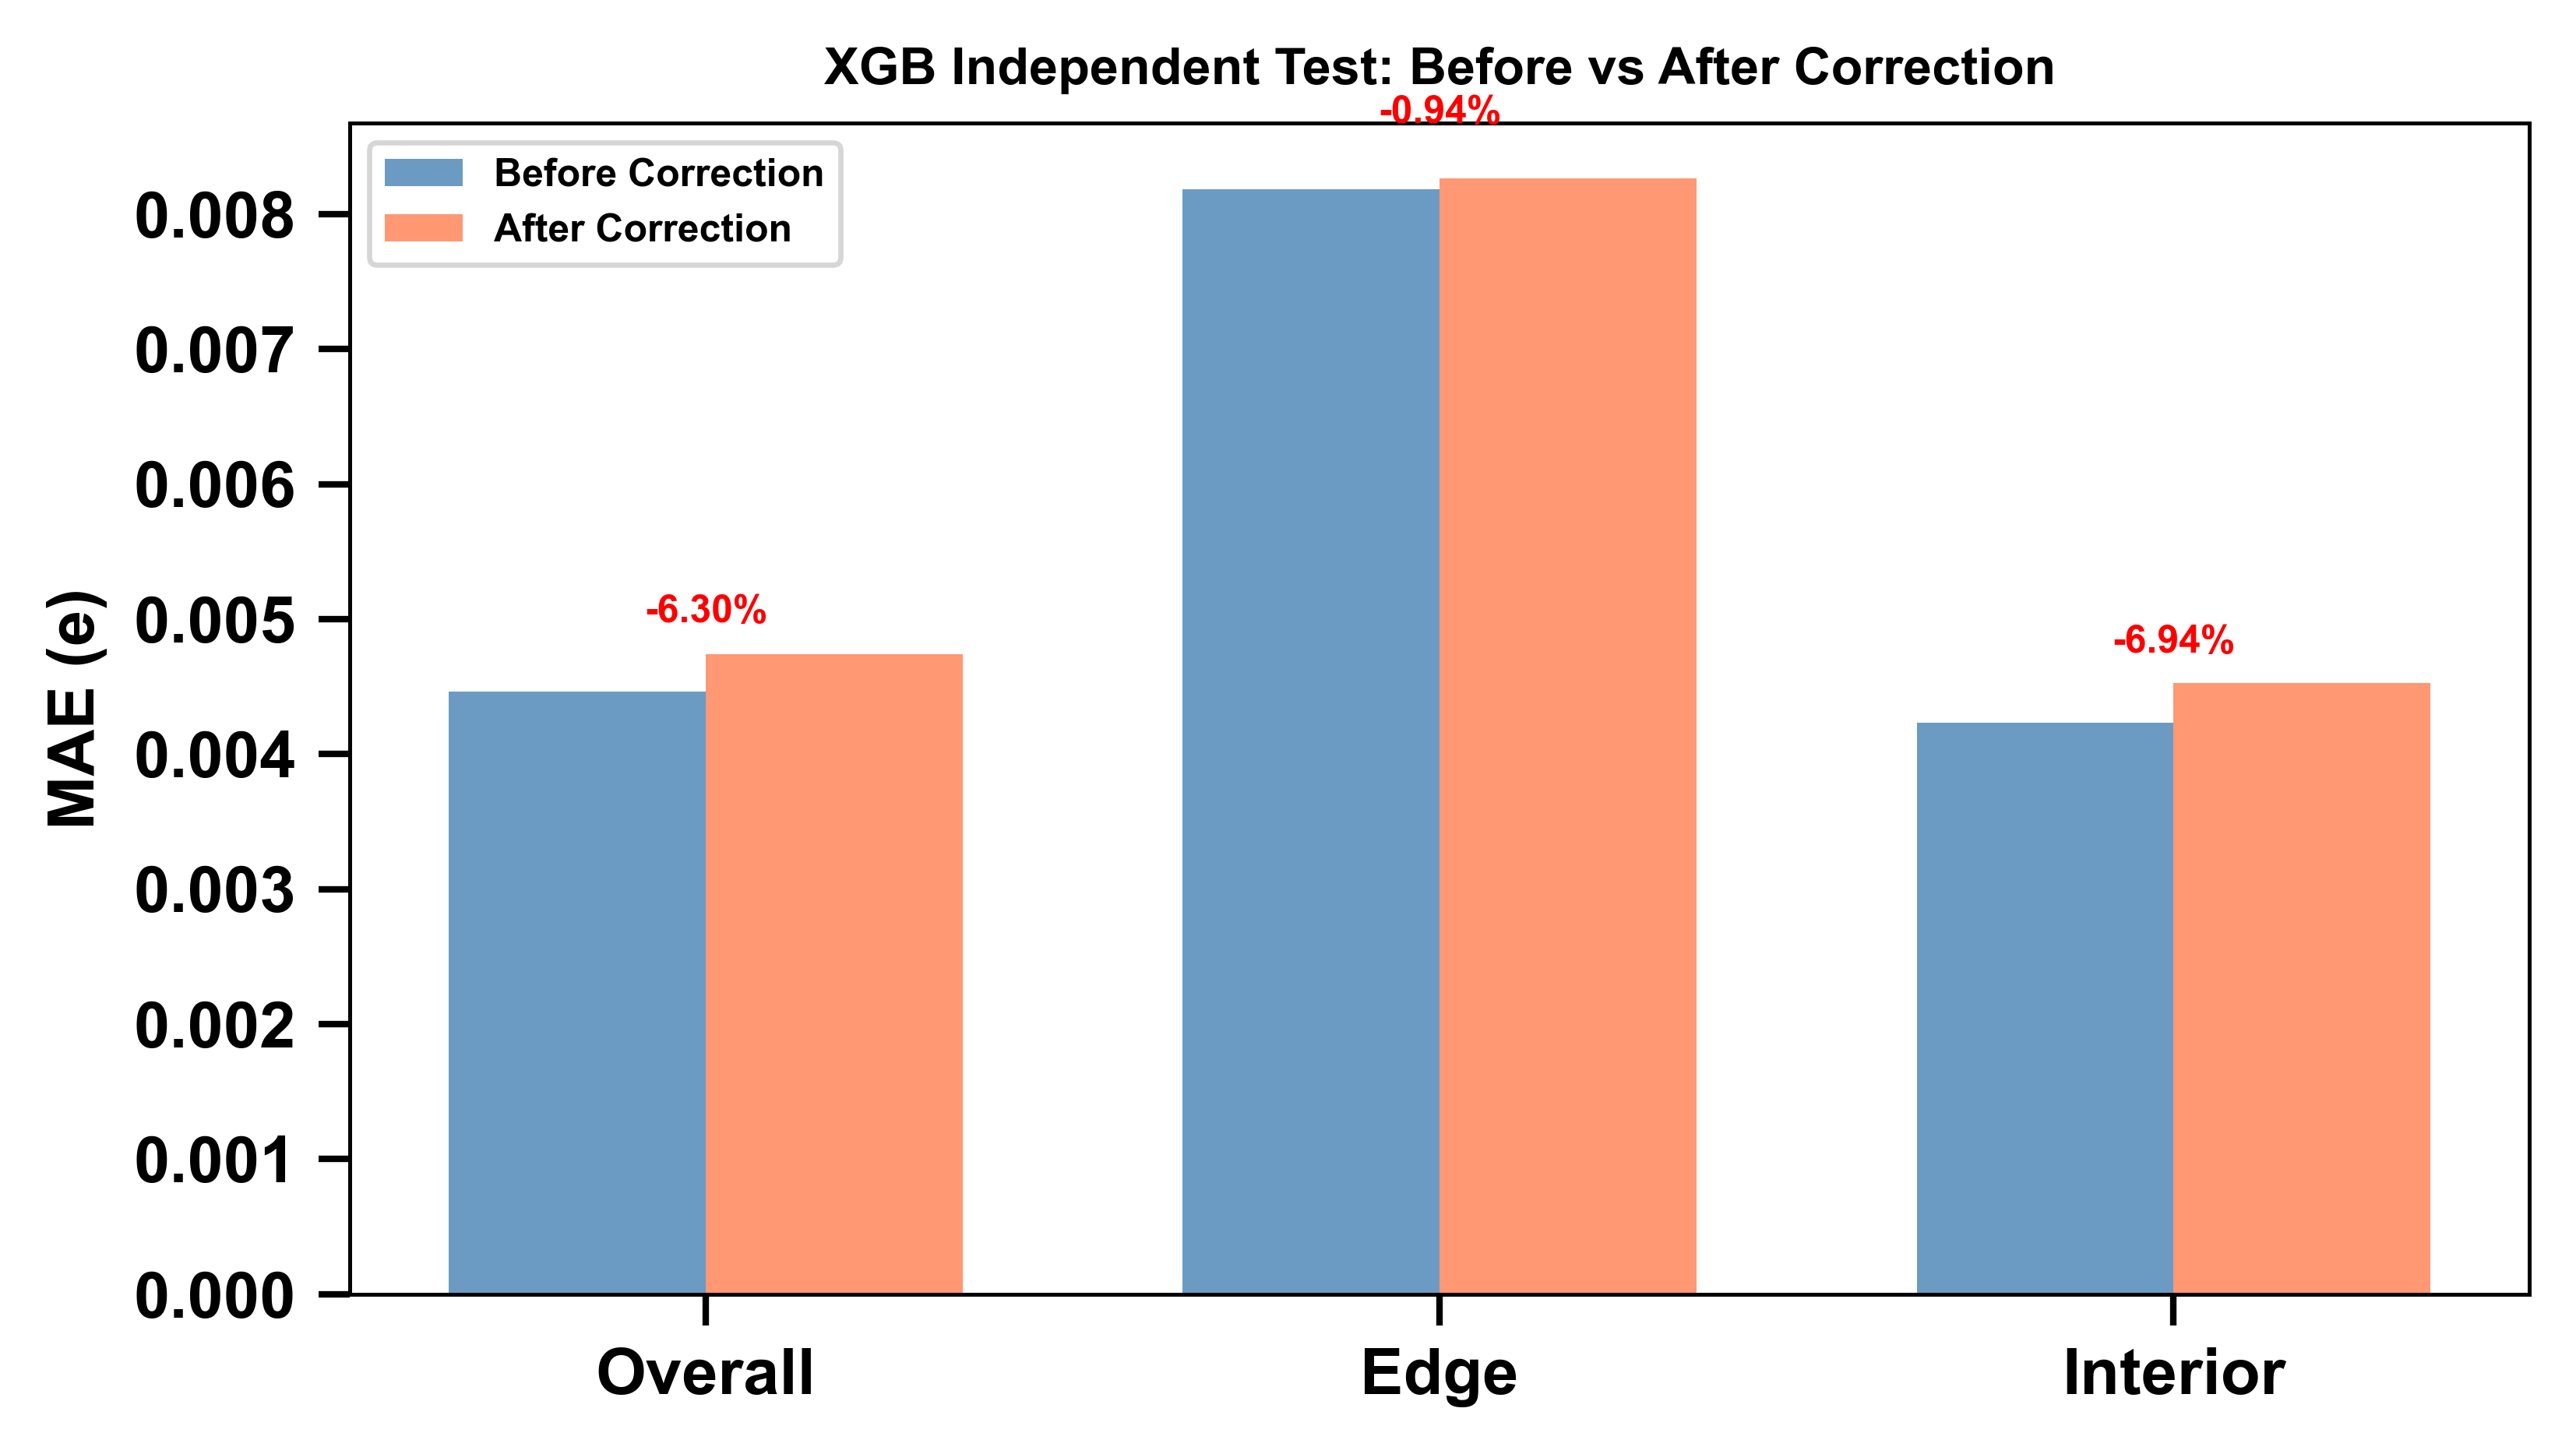

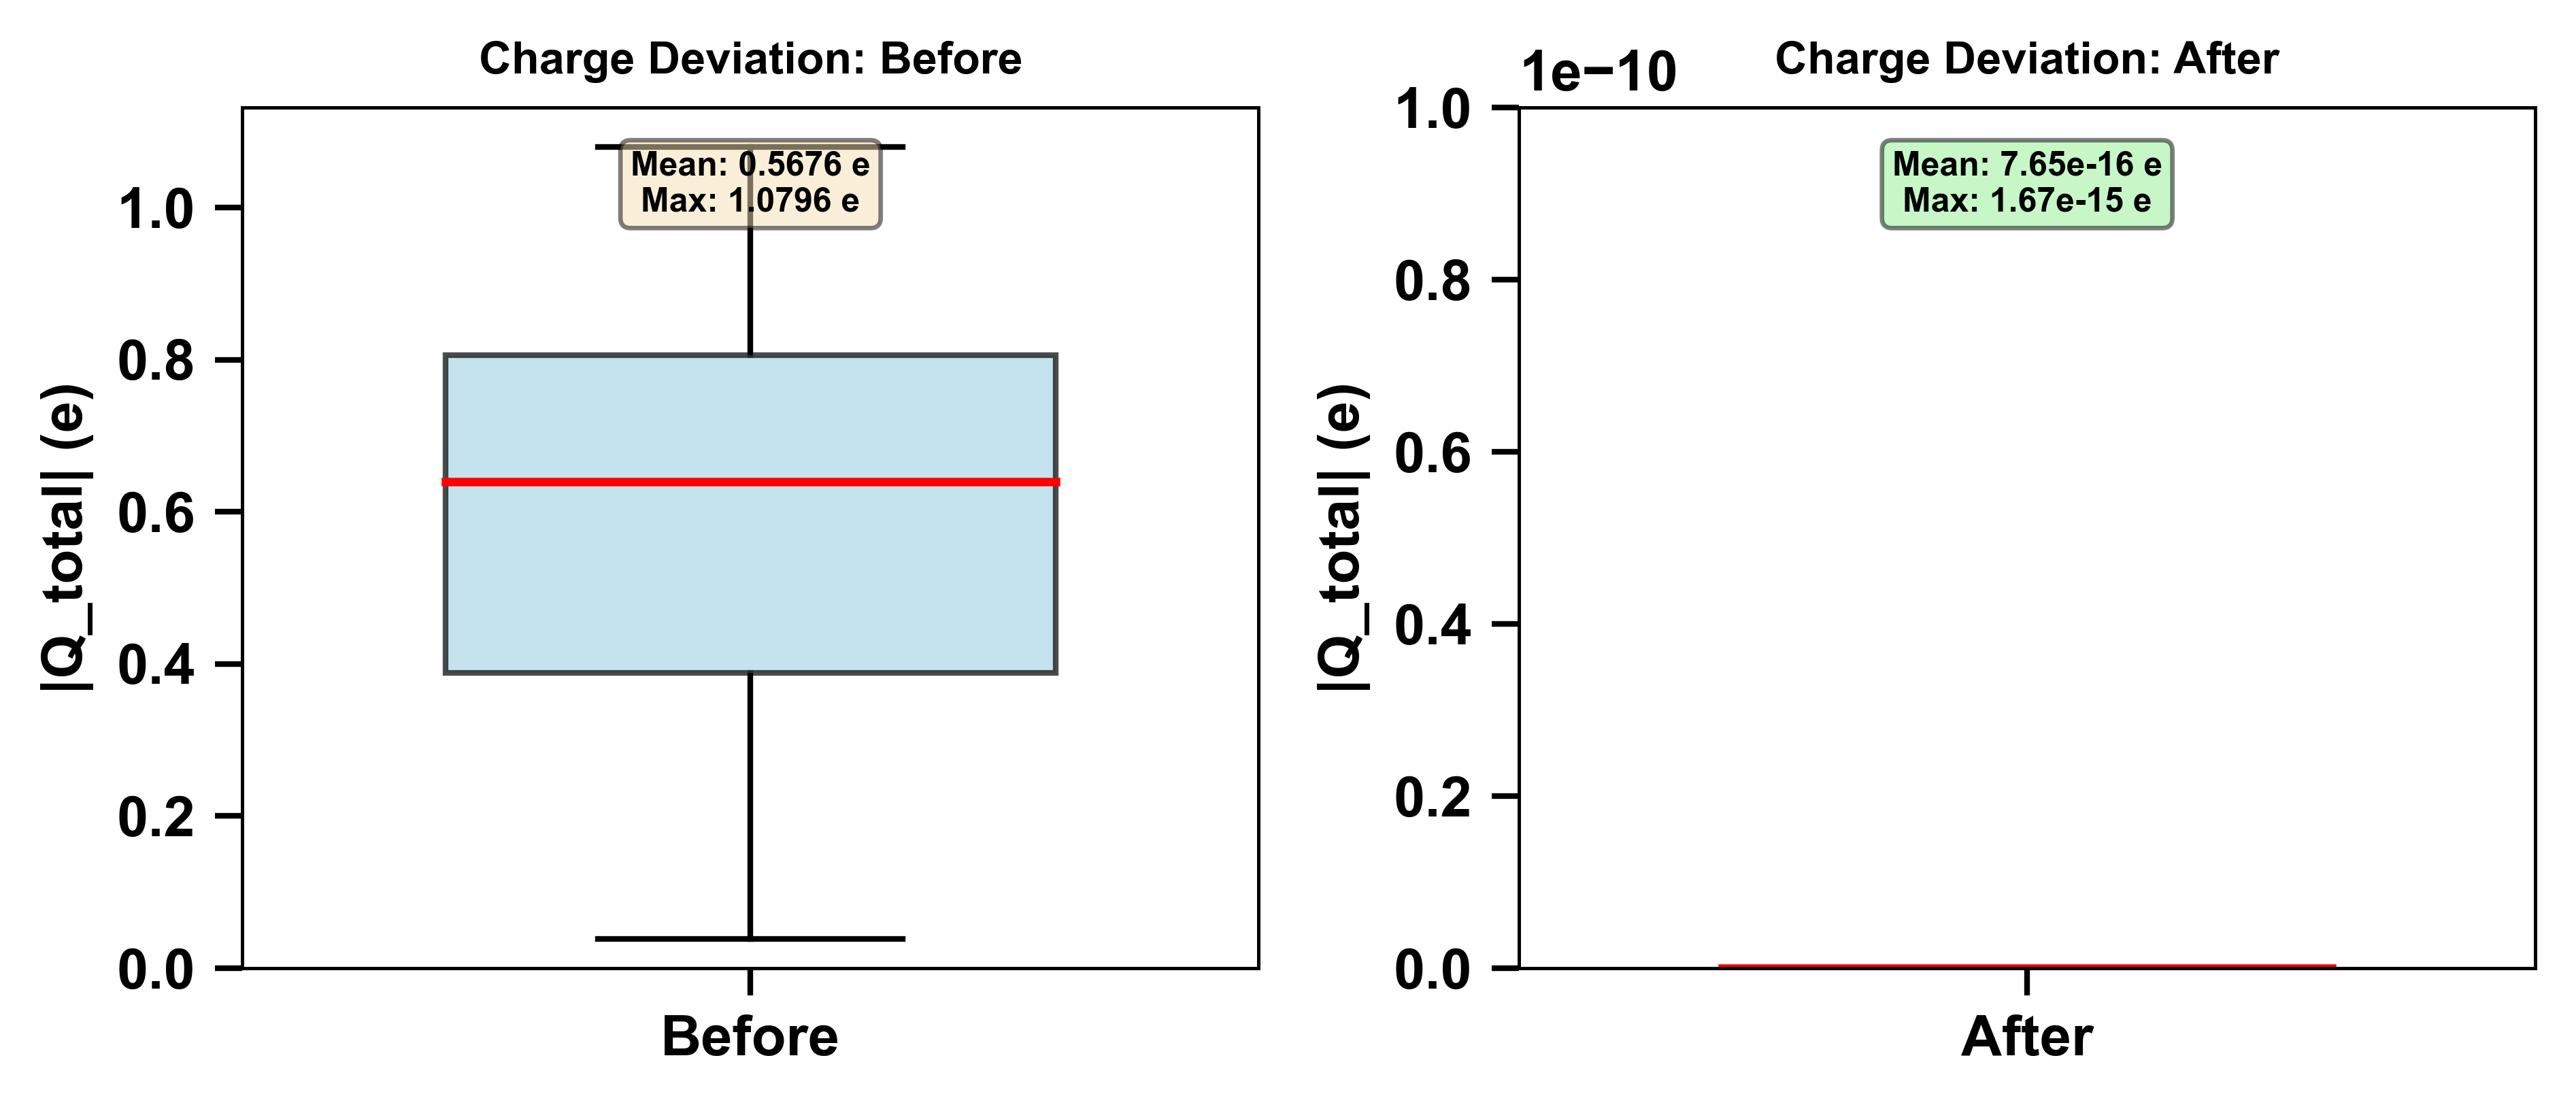

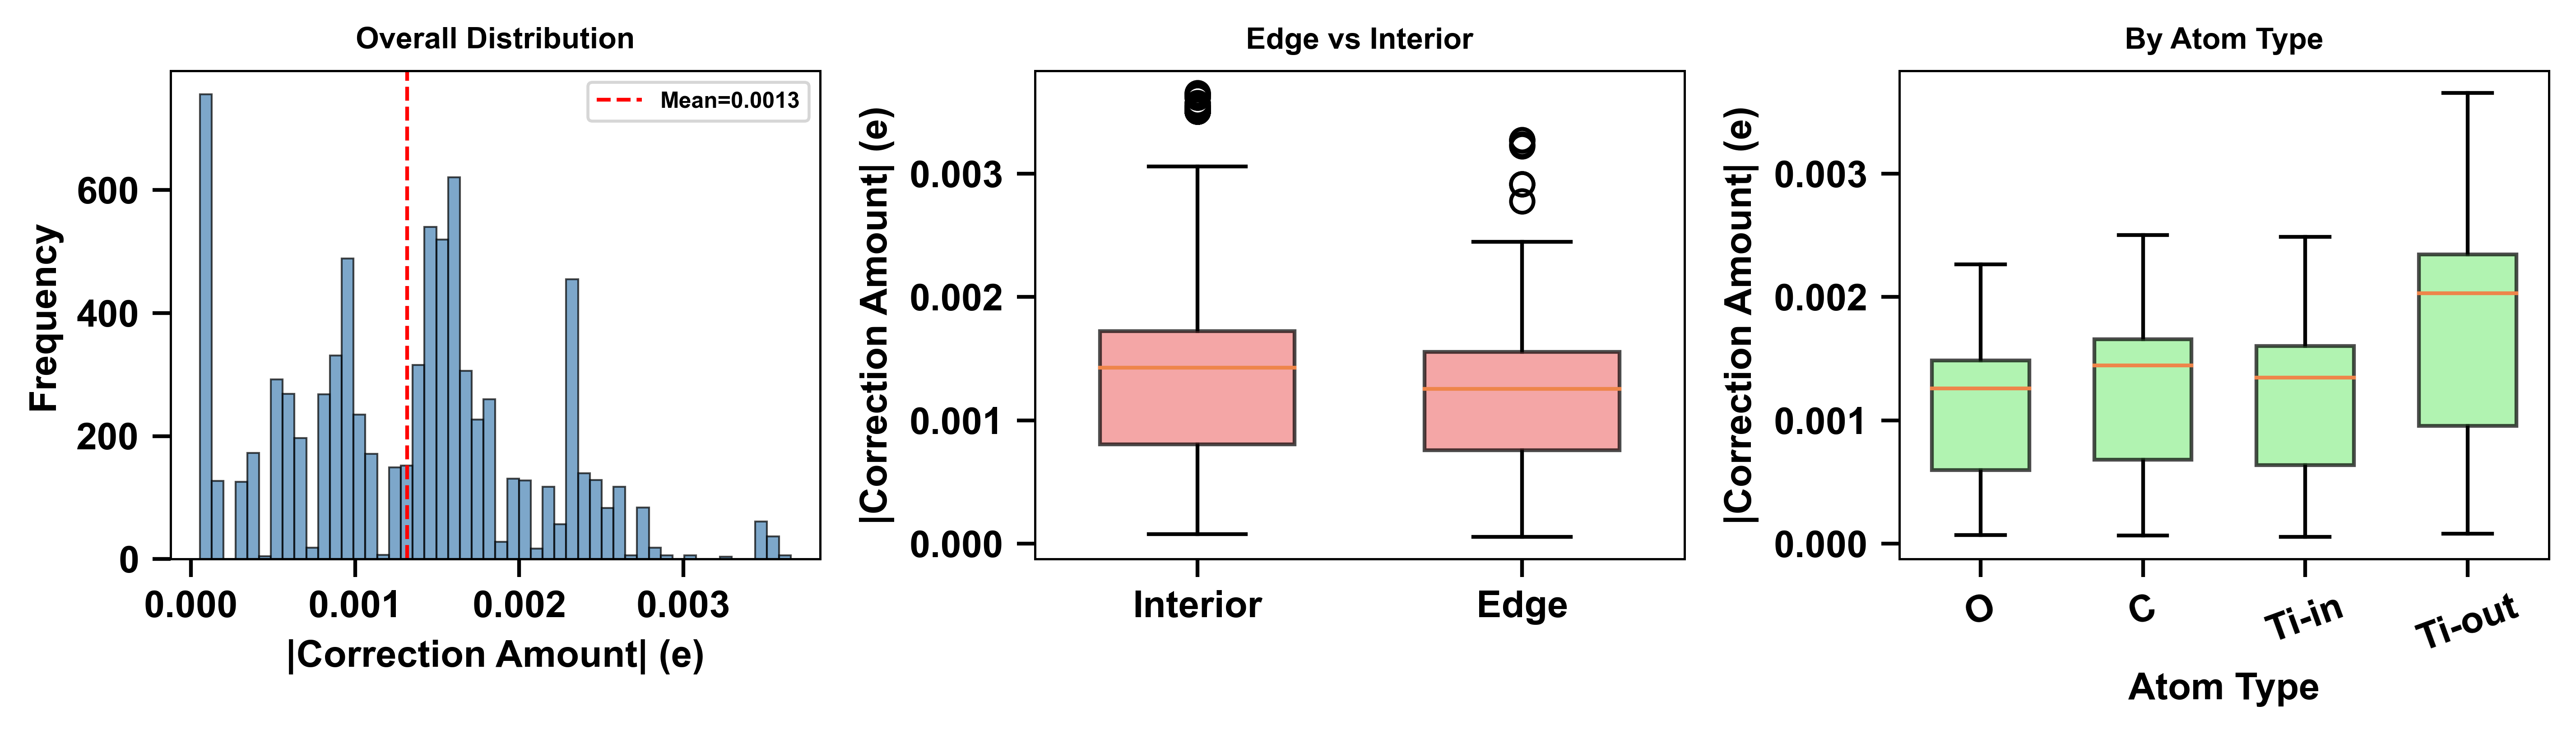

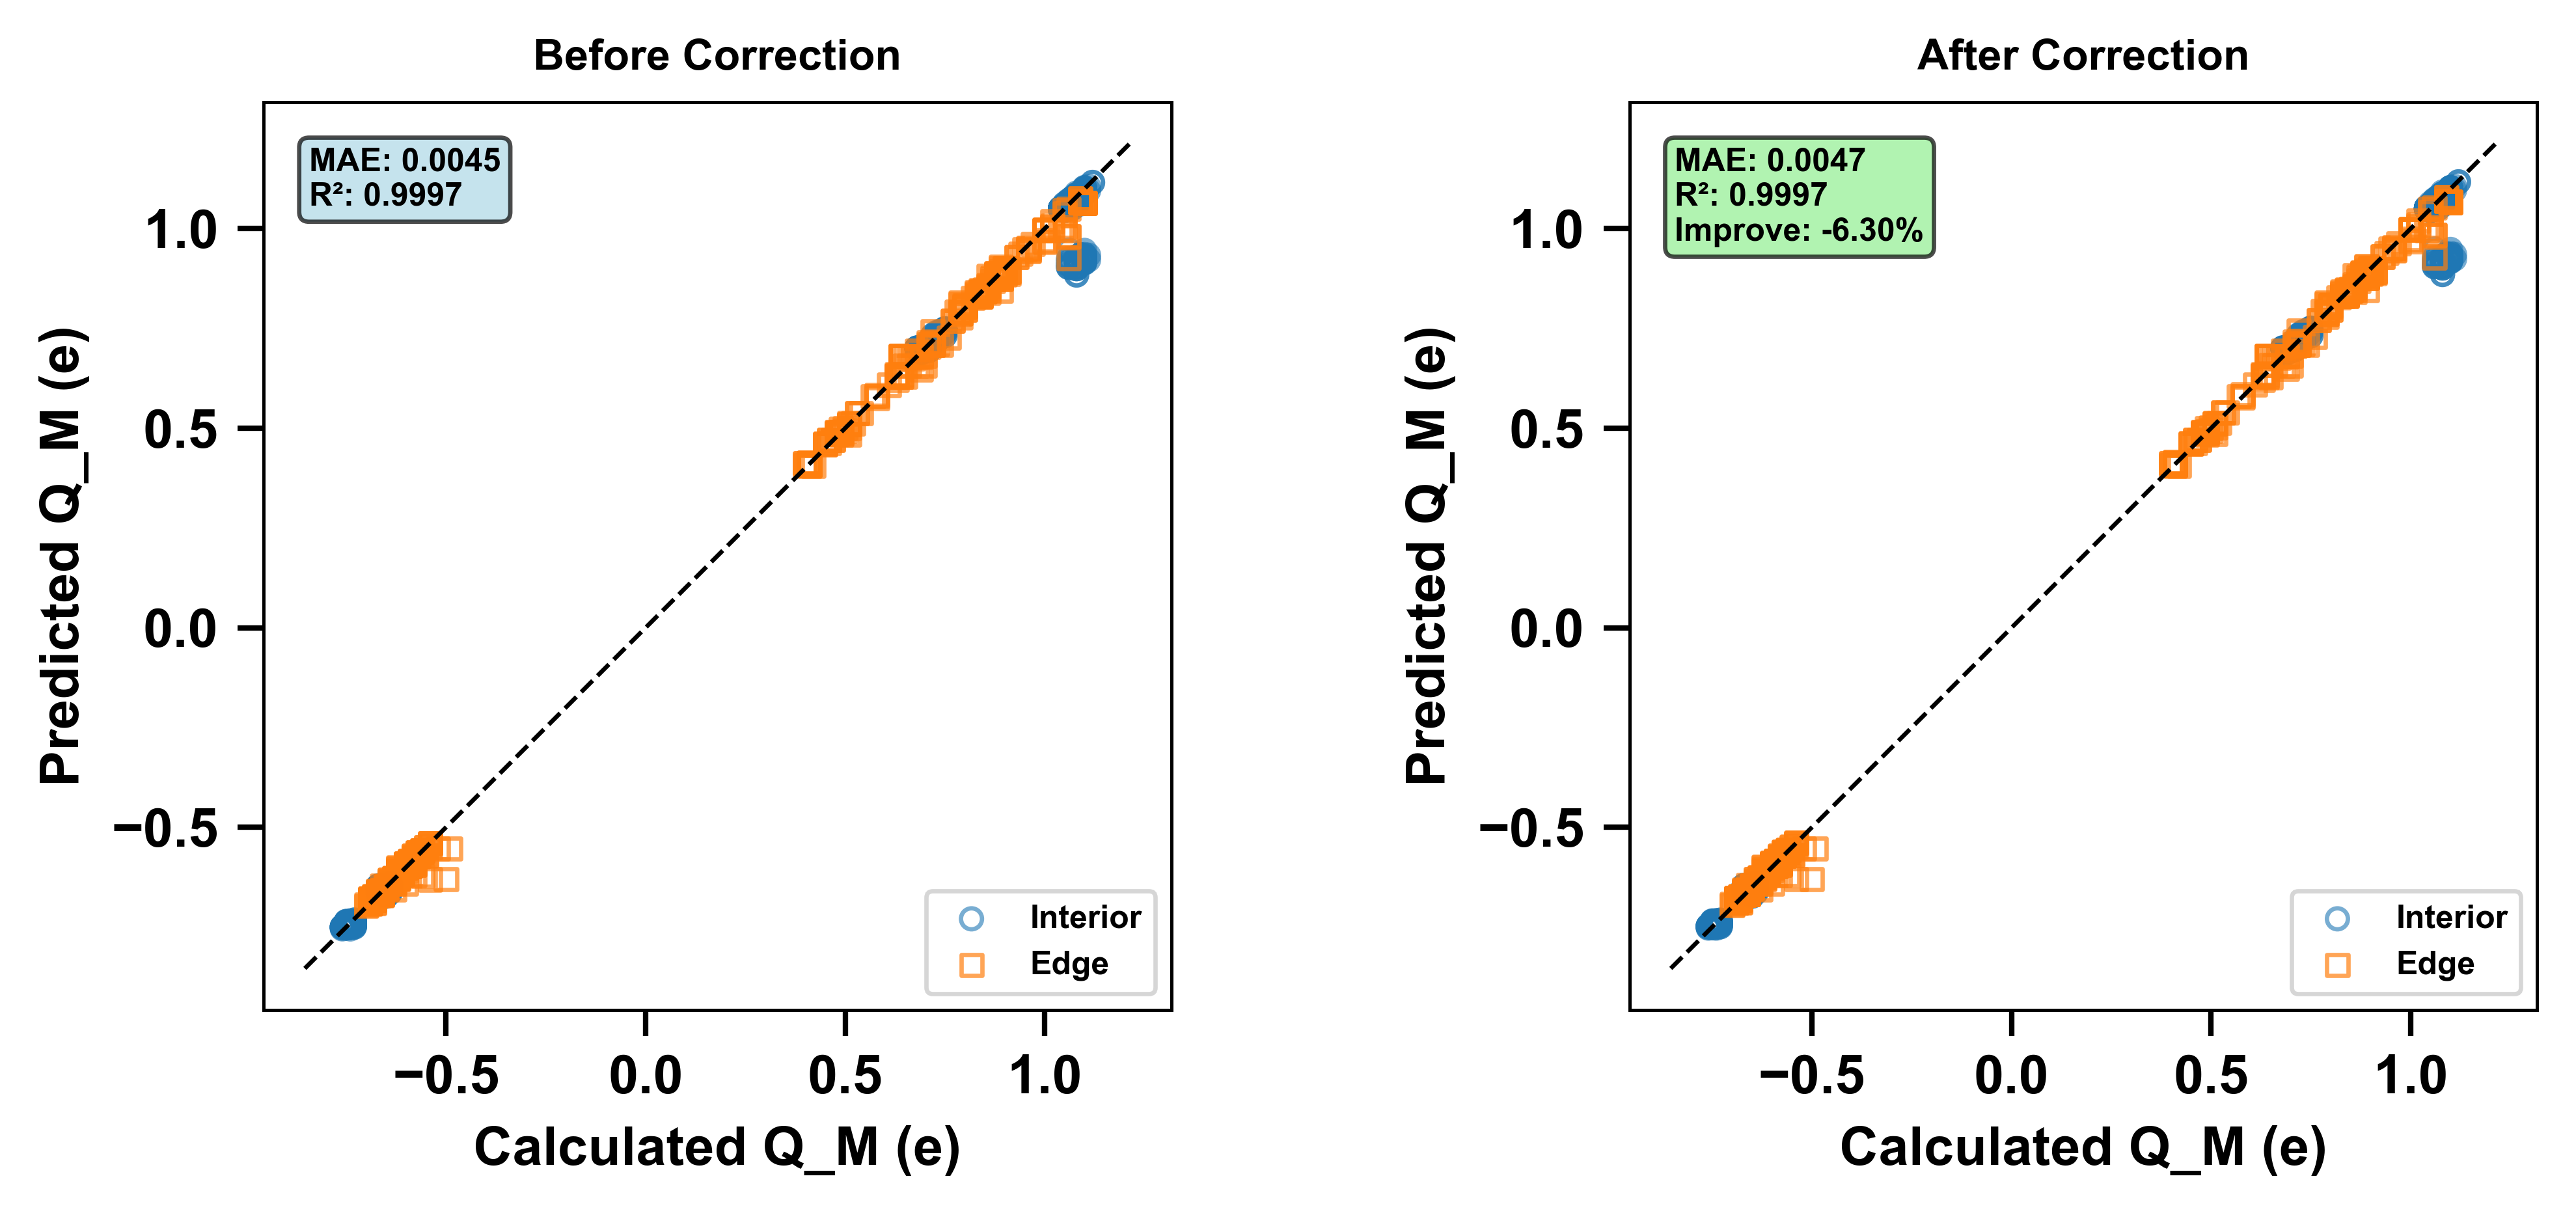

In [2]:
# =============================================================================
# 图表绘制
# =============================================================================

edge_mask     = D_E < EDGE_THRESHOLD
interior_mask = ~edge_mask
width         = 0.35

# 图1：预测vs实际
fig, ax = plt.subplots(figsize=(3.2, 2.8))
ax.scatter(y_true[interior_mask], y_pred_before[interior_mask], s=15, marker='o', facecolors='none',
           edgecolors=COLOR_MAP['interior'], linewidths=0.8, alpha=0.7, label=f'Interior (N={interior_mask.sum()})')
ax.scatter(y_true[edge_mask], y_pred_before[edge_mask], s=15, marker='s', facecolors='none',
           edgecolors=COLOR_MAP['edge'], linewidths=0.8, alpha=0.8, label=f'Edge (N={edge_mask.sum()})')
vmin, vmax = np.concatenate([y_true, y_pred_before]).min(), np.concatenate([y_true, y_pred_before]).max()
margin = (vmax - vmin) * 0.05
ax.plot([vmin-margin, vmax+margin], [vmin-margin, vmax+margin], 'k--', linewidth=ref_line_size)
ax.text(0.05, 0.95,
        f'N = {len(y_true)}\nMAE = {ind_results["overall"]["mae"]:.4f}\n'
        f'R² = {ind_results["overall"]["r2"]:.4f}\nEdge/Int = {ind_ratio:.2f}×',
        transform=ax.transAxes, fontsize=ssss, va='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
ax.set_xlabel('Calculated Q_M (e)'); ax.set_ylabel('Predicted Q_M (e)')
ax.set_title('XGB: Independent Test', fontsize=sss, weight='bold')
ax.legend(fontsize=ssss, frameon=True, loc='lower right'); ax.set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.savefig('figures/independent_test/xgb_01_pred_vs_true.png', dpi=600, bbox_inches='tight')
plt.savefig('figures/independent_test/xgb_01_pred_vs_true.pdf', dpi=600, bbox_inches='tight')
plt.show()

# 图2：残差分析
errors = y_pred_before - y_true
fig, axes = plt.subplots(1, 2, figsize=(6.4, 2.8))
axes[0].hist(errors, bins=50, edgecolor='black', linewidth=0.5, alpha=0.7)
axes[0].axvline(0, color='red', linestyle='--', linewidth=ref_line_size)
axes[0].text(0.05, 0.95, f'μ={np.mean(errors):.4f}\nσ={np.std(errors):.4f}',
             transform=axes[0].transAxes, fontsize=ssss, va='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
axes[0].set_xlabel('Prediction Error (e)', fontsize=ss, weight='bold')
axes[0].set_ylabel('Frequency', fontsize=ss, weight='bold')
axes[0].set_title('Error Distribution', fontsize=sss, weight='bold')
axes[1].scatter(y_true, errors, s=10, alpha=0.5, color='steelblue')
axes[1].axhline(0, color='red', linestyle='--', linewidth=ref_line_size)
axes[1].set_xlabel('True Q_M (e)', fontsize=ss, weight='bold')
axes[1].set_ylabel('Prediction Error (e)', fontsize=ss, weight='bold')
axes[1].set_title('Residuals vs True Values', fontsize=sss, weight='bold')
plt.tight_layout()
plt.savefig('figures/independent_test/xgb_02_residuals.png', dpi=600, bbox_inches='tight')
plt.show()

# 图3：CV vs Independent
fig, ax = plt.subplots(figsize=(5.6, 3.2))
x = np.arange(3)
cv_maes  = [cv_test['overall']['mae_mean'], cv_test['edge']['mae_mean'], cv_test['interior']['mae_mean']]
ind_maes = [ind_results['overall']['mae'],  ind_results['edge']['mae'],  ind_results['interior']['mae']]
ax.bar(x-width/2, cv_maes,  width, label='CV Test (2×3 to 4×7)', alpha=0.8, color=COLOR_MAP['cv'])
ax.bar(x+width/2, ind_maes, width, label='Independent Test',      alpha=0.8, color=COLOR_MAP['independent'])
for i, (cv_m, ind_m, chg) in enumerate(zip(cv_maes, ind_maes, [overall_change, edge_change, interior_change])):
    ax.text(i, max(cv_m, ind_m)*1.05, f'{chg:+.1f}%', ha='center', fontsize=ssss,
            color='red' if chg > 10 else 'green', weight='bold')
ax.set_xticks(x); ax.set_xticklabels(['Overall', 'Edge', 'Interior'])
ax.set_ylabel('MAE (e)', fontsize=ss, weight='bold')
ax.set_title('XGB: CV Test vs Independent Test', fontsize=sss, weight='bold')
ax.legend(fontsize=ssss, frameon=True, loc='upper left')
plt.tight_layout()
plt.savefig('figures/independent_test/xgb_03_cv_vs_independent.png', dpi=600, bbox_inches='tight')
plt.show()

# 图4：边缘vs内部
fig, ax = plt.subplots(figsize=(4.8, 3.2))
x2 = np.arange(2)
cv_ei  = [cv_test['interior']['mae_mean'], cv_test['edge']['mae_mean']]
ind_ei = [ind_results['interior']['mae'],  ind_results['edge']['mae']]
ax.bar(x2-width/2, cv_ei,  width, label='CV Test',    alpha=0.8, color=COLOR_MAP['cv'])
ax.bar(x2+width/2, ind_ei, width, label='Independent', alpha=0.8, color=COLOR_MAP['independent'])
ax.set_xticks(x2); ax.set_xticklabels(['Interior', 'Edge'])
ax.set_ylabel('MAE (e)', fontsize=ss, weight='bold')
ax.set_title('Edge vs Interior: CV vs Independent', fontsize=sss, weight='bold')
ax.legend(fontsize=ssss, frameon=True)
ax.text(1, max(cv_ei+ind_ei)*1.15, f'CV Ratio: {cv_ratio:.2f}×\nInd Ratio: {ind_ratio:.2f}×',
        ha='center', fontsize=ssss, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
plt.tight_layout()
plt.savefig('figures/independent_test/xgb_04_edge_vs_interior.png', dpi=600, bbox_inches='tight')
plt.show()

# 图5：按原子类型
fig, ax = plt.subplots(figsize=(5.6, 3.2))
x3 = np.arange(len(ATOM_TYPE_LABELS))
cv_at  = [cv_test['by_atom_type'][l]['mae_mean'] for l in ATOM_TYPE_LABELS]
ind_at = [ind_results['by_atom_type'][l]['mae']  for l in ATOM_TYPE_LABELS]
ax.bar(x3-width/2, cv_at,  width, label='CV Test',    alpha=0.8, color=COLOR_MAP['cv'])
ax.bar(x3+width/2, ind_at, width, label='Independent', alpha=0.8, color=COLOR_MAP['independent'])
ax.set_xticks(x3); ax.set_xticklabels(['O', 'C', 'Ti-inner', 'Ti-outer'])
ax.set_ylabel('MAE (e)', fontsize=ss, weight='bold'); ax.set_xlabel('Atom Type', fontsize=ss, weight='bold')
ax.set_title('Performance by Atom Type', fontsize=sss, weight='bold')
ax.legend(fontsize=ssss, frameon=True)
plt.tight_layout()
plt.savefig('figures/independent_test/xgb_05_by_atom_type.png', dpi=600, bbox_inches='tight')
plt.show()

# 图6：误差CDF
abs_errors    = np.abs(errors)
sorted_errors = np.sort(abs_errors)
cdf           = np.arange(1, len(sorted_errors)+1) / len(sorted_errors)
fig, ax = plt.subplots(figsize=(4.0, 3.2))
ax.plot(sorted_errors, cdf, linewidth=1.5, color='steelblue', label='Independent Test')
for p in [50, 90, 95, 99]:
    val = np.percentile(abs_errors, p)
    ax.axvline(val, color='gray', linestyle=':', linewidth=0.8, alpha=0.5)
    ax.text(val, 0.05, f'{p}%\n{val:.4f}', fontsize=ssss, ha='left', va='bottom')
ax.set_xlabel('Absolute Error (e)', fontsize=ss, weight='bold')
ax.set_ylabel('Cumulative Probability', fontsize=ss, weight='bold')
ax.set_title('Error Cumulative Distribution', fontsize=sss, weight='bold')
ax.legend(fontsize=ssss, frameon=True); ax.grid(alpha=0.3, linewidth=0.5)
plt.tight_layout()
plt.savefig('figures/independent_test/xgb_06_error_cdf.png', dpi=600, bbox_inches='tight')
plt.show()

# 图7：各结构MAE
structure_maes = [{'structure': sid,
                   'mae': df_predictions[df_predictions['structure_id']==sid]['abs_error'].mean(),
                   'n_atoms': int((df_predictions['structure_id']==sid).sum())}
                  for sid in df_5x6['structure_id'].unique()]
df_struct_mae  = pd.DataFrame(structure_maes).sort_values('mae')
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(range(len(df_struct_mae)), df_struct_mae['mae'], alpha=0.8)
bars[0].set_color('tab:green'); bars[-1].set_color('tab:red')
ax.set_yticks(range(len(df_struct_mae))); ax.set_yticklabels(df_struct_mae['structure'], fontsize=6)
ax.set_xlabel('MAE (e)', fontsize=ss, weight='bold')
ax.set_title('MAE per Structure (Independent Test)', fontsize=sss, weight='bold')
for i, (mae, n) in enumerate(zip(df_struct_mae['mae'], df_struct_mae['n_atoms'])):
    ax.text(mae+0.0002, i, f'N={n}', fontsize=5, va='center')
plt.tight_layout()
plt.savefig('figures/independent_test/xgb_07_mae_per_structure.png', dpi=600, bbox_inches='tight')
plt.show()

# =============================================================================
# 电中性校正相关图表
# =============================================================================

# 图8：校正前后MAE对比
fig, ax = plt.subplots(figsize=(5.6, 3.2))
x4 = np.arange(3)
maes_b = [ind_results_before['overall']['mae'], ind_results_before['edge']['mae'], ind_results_before['interior']['mae']]
maes_a = [ind_results_after['overall']['mae'],  ind_results_after['edge']['mae'],  ind_results_after['interior']['mae']]
ax.bar(x4-width/2, maes_b, width, label='Before Correction', alpha=0.8, color='steelblue')
ax.bar(x4+width/2, maes_a, width, label='After Correction',  alpha=0.8, color='coral')
ax.set_xticks(x4); ax.set_xticklabels(['Overall', 'Edge', 'Interior'])
ax.set_ylabel('MAE (e)', fontsize=ss, weight='bold')
ax.set_title('XGB Independent Test: Before vs After Correction', fontsize=sss, weight='bold')
ax.legend(fontsize=ssss, frameon=True, loc='upper left')
for i in range(3):
    imp = (maes_b[i]-maes_a[i])/maes_b[i]*100
    ax.text(i, max(maes_b[i], maes_a[i])*1.05, f'{imp:+.2f}%', ha='center',
            fontsize=ssss, color='green' if imp > 0 else 'red', weight='bold')
plt.tight_layout()
plt.savefig('figures/independent_test/xgb_08_correction_comparison.png', dpi=600, bbox_inches='tight')
plt.show()

# 图9：总电荷偏差
fig, axes = plt.subplots(1, 2, figsize=(6.4, 2.8))
axes[0].boxplot([np.abs(Q_total_before)], labels=['Before'], widths=0.6, patch_artist=True,
                boxprops=dict(facecolor='lightblue', alpha=0.7), medianprops=dict(color='red', linewidth=1.5))
axes[0].set_ylabel('|Q_total| (e)', fontsize=ss, weight='bold')
axes[0].set_title('Charge Deviation: Before', fontsize=sss, weight='bold'); axes[0].set_ylim(bottom=0)
axes[0].text(0.5, 0.95, f'Mean: {np.abs(Q_total_before).mean():.4f} e\nMax: {np.abs(Q_total_before).max():.4f} e',
             transform=axes[0].transAxes, fontsize=ssss, ha='center', va='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
max_after = np.abs(Q_total_after).max()
axes[1].boxplot([np.abs(Q_total_after)], labels=['After'], widths=0.6, patch_artist=True,
                boxprops=dict(facecolor='lightgreen', alpha=0.7), medianprops=dict(color='red', linewidth=1.5))
axes[1].set_ylabel('|Q_total| (e)', fontsize=ss, weight='bold')
axes[1].set_title('Charge Deviation: After', fontsize=sss, weight='bold')
axes[1].set_ylim([0, max(max_after*2, 1e-10)])
axes[1].text(0.5, 0.95, f'Mean: {np.abs(Q_total_after).mean():.2e} e\nMax: {max_after:.2e} e',
             transform=axes[1].transAxes, fontsize=ssss, ha='center', va='top',
             bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))
plt.tight_layout()
plt.savefig('figures/independent_test/xgb_09_charge_deviation.png', dpi=600, bbox_inches='tight')
plt.show()

# 图10：校正量统计
fig, axes = plt.subplots(1, 3, figsize=(9.6, 2.8))
mean_corr = df_predictions['correction_amount'].abs().mean()
axes[0].hist(df_predictions['correction_amount'].abs(), bins=50, alpha=0.7, color='steelblue',
             edgecolor='black', linewidth=0.5)
axes[0].axvline(mean_corr, color='red', linestyle='--', linewidth=1, label=f'Mean={mean_corr:.4f}')
axes[0].set_xlabel('|Correction Amount| (e)', fontsize=ss, weight='bold')
axes[0].set_ylabel('Frequency', fontsize=ss, weight='bold')
axes[0].set_title('Overall Distribution', fontsize=sss, weight='bold'); axes[0].legend(fontsize=ssss)
bp = axes[1].boxplot([df_predictions.loc[interior_mask,'correction_amount'].abs(),
                       df_predictions.loc[edge_mask,'correction_amount'].abs()],
                      labels=['Interior','Edge'], widths=0.6, patch_artist=True)
for p in bp['boxes']: p.set_facecolor('lightcoral'); p.set_alpha(0.7)
axes[1].set_ylabel('|Correction Amount| (e)', fontsize=ss, weight='bold')
axes[1].set_title('Edge vs Interior', fontsize=sss, weight='bold')
atom_corr_data = [df_predictions.loc[df_5x6[col].values==1, 'correction_amount'].abs() for col in ATOM_TYPE_COLS]
bp2 = axes[2].boxplot(atom_corr_data, labels=['O','C','Ti-in','Ti-out'], widths=0.6, patch_artist=True)
for p in bp2['boxes']: p.set_facecolor('lightgreen'); p.set_alpha(0.7)
axes[2].set_ylabel('|Correction Amount| (e)', fontsize=ss, weight='bold')
axes[2].set_xlabel('Atom Type', fontsize=ss, weight='bold')
axes[2].set_title('By Atom Type', fontsize=sss, weight='bold'); axes[2].tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.savefig('figures/independent_test/xgb_10_correction_amount.png', dpi=600, bbox_inches='tight')
plt.show()

# 图11：校正前后散点图对比
all_vals = np.concatenate([y_true, y_pred_before, y_pred_after])
vmin, vmax = all_vals.min(), all_vals.max(); margin = (vmax-vmin)*0.05
fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.2))
for ax, y_pp, title, clr, lbl in [
    (axes[0], y_pred_before, 'Before Correction', 'lightblue',
     f'MAE: {ind_results_before["overall"]["mae"]:.4f}\nR²: {ind_results_before["overall"]["r2"]:.4f}'),
    (axes[1], y_pred_after,  'After Correction',  'lightgreen',
     f'MAE: {ind_results_after["overall"]["mae"]:.4f}\nR²: {ind_results_after["overall"]["r2"]:.4f}\n'
     f'Improve: {mae_improvement:+.2f}%')
]:
    ax.scatter(y_true[interior_mask], y_pp[interior_mask], s=15, marker='o', facecolors='none',
               edgecolors=COLOR_MAP['interior'], linewidths=0.8, alpha=0.6, label='Interior')
    ax.scatter(y_true[edge_mask], y_pp[edge_mask], s=15, marker='s', facecolors='none',
               edgecolors=COLOR_MAP['edge'], linewidths=0.8, alpha=0.7, label='Edge')
    ax.plot([vmin-margin, vmax+margin], [vmin-margin, vmax+margin], 'k--', linewidth=ref_line_size)
    ax.set_xlabel('Calculated Q_M (e)', fontsize=ss, weight='bold')
    ax.set_ylabel('Predicted Q_M (e)', fontsize=ss, weight='bold')
    ax.set_title(title, fontsize=sss, weight='bold')
    ax.legend(fontsize=ssss, frameon=True, loc='lower right'); ax.set_aspect('equal', adjustable='box')
    ax.text(0.05, 0.95, lbl, transform=ax.transAxes, fontsize=ssss, va='top',
            bbox=dict(boxstyle='round', facecolor=clr, alpha=0.7))
plt.tight_layout()
plt.savefig('figures/independent_test/xgb_11_scatter_comparison.png', dpi=600, bbox_inches='tight')
plt.show()



In [3]:
# =============================================================================
# 保存结果文件
# =============================================================================

df_predictions.to_csv('models/xgb/independent_test_predictions.csv', index=False)

def build_scores_rows(ind_results, atom_type_labels):
    rows = []
    for cat in ['overall', 'edge', 'interior']:
        d = ind_results[cat]
        rows.append({'category': cat, 'subcategory': 'all',
                     'mae': d['mae'], 'rmse': d['rmse'], 'r2': d['r2'], 'n_samples': d['n_samples']})
    for label in atom_type_labels:
        d = ind_results['by_atom_type'][label]
        rows.append({'category': 'atom_type', 'subcategory': label,
                     'mae': d['mae'], 'rmse': d['rmse'], 'r2': d['r2'], 'n_samples': d['n_samples']})
    return rows

pd.DataFrame(build_scores_rows(ind_results_before, ATOM_TYPE_LABELS)).to_csv(
    'models/xgb/independent_test_scores.csv', index=False)
pd.DataFrame(build_scores_rows(ind_results_after, ATOM_TYPE_LABELS)).to_csv(
    'models/xgb/independent_test_scores_corrected.csv', index=False)

comparison_rows = []
for cat, subcat in [('overall','all'),('edge','all'),('interior','all')] + [('atom_type',l) for l in ATOM_TYPE_LABELS]:
    mb = ind_results_before['by_atom_type'][subcat]['mae'] if cat=='atom_type' else ind_results_before[cat]['mae']
    ma = ind_results_after['by_atom_type'][subcat]['mae']  if cat=='atom_type' else ind_results_after[cat]['mae']
    comparison_rows.append({'category': cat, 'subcategory': subcat,
                            'mae_before': mb, 'mae_after': ma, 'mae_improvement_percent': (mb-ma)/mb*100})
pd.DataFrame(comparison_rows).to_csv('models/xgb/independent_test_correction_comparison.csv', index=False)

full_results = {
    'model_name': 'XGB', 'n_structures': int(df_5x6['structure_id'].nunique()),
    'n_atoms': int(len(df_5x6)), 'edge_threshold': EDGE_THRESHOLD,
    'before_correction': {'overall': ind_results_before['overall'], 'edge': ind_results_before['edge'],
                          'interior': ind_results_before['interior'], 'by_atom_type': ind_results_before['by_atom_type']},
    'after_correction':  {'overall': ind_results_after['overall'],  'edge': ind_results_after['edge'],
                          'interior': ind_results_after['interior'],  'by_atom_type': ind_results_after['by_atom_type']},
    'correction_stats': {
        'mean_Q_total_before': float(np.abs(Q_total_before).mean()),
        'max_Q_total_before':  float(np.abs(Q_total_before).max()),
        'mean_Q_total_after':  float(np.abs(Q_total_after).mean()),
        'max_Q_total_after':   float(np.abs(Q_total_after).max()),
        'mean_correction_amount': float(df_predictions['correction_amount'].abs().mean()),
        'max_correction_amount':  float(df_predictions['correction_amount'].abs().max()),
        'mae_improvement_percent': float(mae_improvement)
    },
    'cv_comparison': {
        'cv_test_mae': cv_test['overall']['mae_mean'],
        'independent_mae_before': ind_results_before['overall']['mae'],
        'independent_mae_after':  ind_results_after['overall']['mae'],
        'mae_change_pct': float(overall_change),
        'edge_ratio_cv': float(cv_ratio),
        'edge_ratio_independent_before': float(ind_ratio),
        'edge_ratio_independent_after':  float(ind_ratio_after)
    },
    'model_info': {'best_params': best_params, 'feature_count': len(feature_cols)}
}
with open('models/xgb/independent_test_results.json', 'w') as f:
    json.dump(full_results, f, indent=4)

print("\n已保存: independent_test_predictions.csv, independent_test_scores.csv, "
      "independent_test_scores_corrected.csv, independent_test_correction_comparison.csv, "
      "independent_test_results.json")
print(f"校正前 MAE: {ind_results_before['overall']['mae']:.5f}  "
      f"校正后 MAE: {ind_results_after['overall']['mae']:.5f}  改善: {mae_improvement:+.2f}%")


已保存: independent_test_predictions.csv, independent_test_scores.csv, independent_test_scores_corrected.csv, independent_test_correction_comparison.csv, independent_test_results.json
校正前 MAE: 0.00446  校正后 MAE: 0.00474  改善: -6.30%
